# Tennessee Eastman Process (TEP): Synthetic data generation and domain bridging
Building directly upon the empirical domain-shift characterization from **Stage 2**, 
we deploy **Conditional Variational Autoencoders (CVAE)** and **Conditional Generative Adversarial Networks (CGAN)** 
to bridge the physical domain gap between source and target regimes. 

To establish direct experimental parity with Stage 2, this stage executes **two independent tracks evaluated on the exact same domain configurations and baselines**:

| Track | Industrial Objective | Stage 2 Baseline Counterpart  | Target Evaluation Metric |
| :--- | :--- | :--- | :--- |
| **Part I: Binary Track** | **Fault Detection** (*Normal vs. Fault-Active*) | 20 Binary Pairs (Unaugmented Transfer) | Binary Transfer F1 and Transfer Penalty |
| **Part II: Multiclass Track** | **Fault Diagnosis** (*Mechanisms 0..5*) | Cross-Category Multiclass Transfers | Multiclass Macro-F1 and Balanced Accuracy |

### Experimental alignment and integrity
1. **Direct stage 2 alignment**: The evaluated domain pairs, input feature sets, and source/target assignments remain identical to Stage 2, isolating generative augmentation as the sole experimental variable.
2. **Train-test separation**: Target test data (`split = 'test'`) remains completely frozen and is used exclusively for final evaluation.
3. **Training Protocol**: Few-shot target budgets ($+N$ real) and generative models (CVAE/CGAN) utilize data strictly from the training split.
4. **Systematic budget scaling**: All 20 binary pairs and cross-category multiclass configurations are evaluated across expanding synthetic and few-shot budgets ($+N\text{ real}$, $+N/5N/10N\text{ CVAE/CGAN}$) to measure penalty reduction against unaugmented Stage 2 baselines.

## 1. Setup and environment configuration


In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
import os
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.linalg
import matplotlib.pyplot as plt
from pathlib import Path
try:
    import pyreadr
except ImportError:
    pyreadr = None
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, balanced_accuracy_score, confusion_matrix
from sklearn.exceptions import ConvergenceWarning
from scipy.stats import wasserstein_distance
import joblib

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(iterable, *args, **kwargs):
        return iterable
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn.utils.parallel')
warnings.filterwarnings('ignore', category=UserWarning, message=r'.*sklearn\.utils\.parallel\.delayed.*')
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings("ignore", message="y_pred contains classes not in y_true")
sns.set_theme(style='whitegrid', palette='muted')

SEED = 42
def set_seed(seed: int = SEED) -> None:
    """Set deterministic random seeds across PyTorch, NumPy, and Python random.

    Args:
        seed (int): Random seed value.

    Returns:
        None: Sets global deterministic random seeds.
    """
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed()

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using Device: {DEVICE}')


current_dir = Path(os.getcwd())
if (current_dir / "data" / "Tennessee_Eastman_Process_Simulation_Dataset").exists():
    base_project_dir = current_dir
elif (current_dir.parent / "data" / "Tennessee_Eastman_Process_Simulation_Dataset").exists():
    base_project_dir = current_dir.parent
else:
    base_project_dir = current_dir
base_data_path = base_project_dir / "data" / "Tennessee_Eastman_Process_Simulation_Dataset" / "archive"
save_path      = base_project_dir / "data" / "Tennessee_Eastman_Process_Simulation_Dataset" / "processed_csv"
features_path  = base_project_dir / "data" / "Tennessee_Eastman_Process_Simulation_Dataset" / "features"
save_path.mkdir(parents=True, exist_ok=True)
features_path.mkdir(parents=True, exist_ok=True)



Using Device: cpu


## 2. Data loading and feature caching protocol



In [28]:
SUBSAMPLE   = 1
WINDOW_SIZE = 30
STEP        = 20 # 33.3% WINDOW OVERLAP (30 samples window, step 20)

MAX_RUNS_TRAIN = 80
MAX_RUNS_TEST  = 100

RAW_FILES = {
    "fault_free_train": "TEP_FaultFree_Training.RData",
    "fault_free_test":  "TEP_FaultFree_Testing.RData",
    "faulty_train":     "TEP_Faulty_Training.RData",
    "faulty_test":      "TEP_Faulty_Testing.RData",
}
df_header = pd.read_csv(save_path / "fault_free_train.csv", nrows=1)
SENSOR_COLUMNS = [c for c in df_header.columns if c not in ("faultNumber", "simulationRun", "sample")]

def load_raw_tep_data(raw_files: dict) -> dict:
    """Load raw TEP data files into pandas DataFrames and cache as CSVs.

    Args:
        raw_files (dict): Dictionary mapping dataset keys to filenames.

    Returns:
        dict: Dictionary containing loaded pandas DataFrames.
    """
    dfs = {}
    for key, filename in raw_files.items():
        csv_path = save_path / f"{key}.csv"

        if csv_path.exists():
            print(f"[cache] {key}: loading from {csv_path.name}")
            dfs[key] = pd.read_csv(csv_path, dtype=np.float32)
            continue

        rdata_path = base_data_path / filename
        if not rdata_path.exists():
            raise FileNotFoundError(
                f"Could not find {filename} in {base_data_path}. "
            )

        print(f"[convert] {key}: reading {filename}")
        r_data = pyreadr.read_r(rdata_path)
        object_name = list(r_data.keys())[0]
        dfs[key] = r_data[object_name]
        dfs[key].to_csv(csv_path, index=False)
        print(f"[convert] {key}: cached to {csv_path.name}")

    return dfs

all_features_cached = all(
    (features_path / f"fault_{f_idx}_{sp}_w{WINDOW_SIZE}_s{STEP}_sub{SUBSAMPLE}_r{r_num}.csv").exists()
    for f_idx in range(0, 21)
    for sp, r_num in [('train', MAX_RUNS_TRAIN), ('test', MAX_RUNS_TEST)]
)

if not all_features_cached:
    dfs = load_raw_tep_data(RAW_FILES)
    df_fault_free_train = dfs["fault_free_train"]
    df_fault_free_test  = dfs["fault_free_test"]
    df_faulty_train     = dfs["faulty_train"]
    df_faulty_test      = dfs["faulty_test"]
else:
    print("[cache] All 21 fault window feature CSVs found in features. Skipping raw CSV memory load.")
    df_fault_free_train = pd.DataFrame()
    df_fault_free_test  = pd.DataFrame()
    df_faulty_train     = pd.DataFrame()
    df_faulty_test      = pd.DataFrame()

print(f"\nSensor/actuator variables: {len(SENSOR_COLUMNS)}")


[cache] All 21 fault window feature CSVs found in features. Skipping raw CSV memory load.

Sensor/actuator variables: 52


## 3. Feature engineering: sliding-window statistical descriptors

To capture temporal dynamics and multivariate process correlations, we use the same  sliding window of stage 2.
- **Window size**: `WINDOW_SIZE = 30` samples ($1.5 \text{ hours}$ of process operation)
- **Window step**: `STEP = 20` samples ($33.3\%$ window overlap)
- **Statistical descriptors**: 4 rolling statistics per variable (`mean`, `std`, `min`, `max`), yielding a **208-dimensional feature vector** per window.
- **Pre-fault cutoff**: Samples before fault injection (sample 20 in `train`, sample 160 in `test`) are removed to focus exclusively on active faults.

In [29]:
STAT_NAMES  = ['mean', 'std', 'min', 'max']
FEATURE_NAMES = [f'{v}_{s}' for v in SENSOR_COLUMNS for s in STAT_NAMES]


def extract_window_features(df_raw, split):
    """Extracts 208 rolling statistical features (mean, std, min, max) across sliding windows (size=30, step=20)
    Args
    df_raw : pd.DataFrame
        Raw time-series observations for a specific fault or fault-free split.
    split : str
        Data split identifier ('train' or 'test') to enforce sample cutoff rules.

    Returns
    tuple of (np.ndarray, np.ndarray)
        Feature matrix of shape (N, 208) and corresponding binary target labels.
    """
    if df_raw.empty:
        return np.array([]), np.array([])
    
    if 'simulationRun' in df_raw.columns:
        max_runs = MAX_RUNS_TRAIN if split == 'train' else MAX_RUNS_TEST
        available_runs = df_raw['simulationRun'].unique()
        selected_runs = available_runs[:max_runs]
        df_raw = df_raw[df_raw['simulationRun'].isin(selected_runs)].copy()

    inflection = 20 if split == 'train' else 160
    
    df_sub = df_raw.iloc[::SUBSAMPLE].copy()
    grouped = df_sub.groupby('simulationRun') if 'simulationRun' in df_sub.columns else [(None, df_sub)]
    
    feats, tgts = [], []
    for _, group in grouped:
        if len(group) < WINDOW_SIZE:
            continue
        fault_label = group['faultNumber'].iloc[0] if 'faultNumber' in group.columns else 0
        

        rolling = group[SENSOR_COLUMNS].rolling(window=WINDOW_SIZE)
        stat_frames = {
            'mean': rolling.mean(),
            'std':  rolling.std(),
            'min':  rolling.min(),
            'max':  rolling.max(),
        }
        
        run_stats = pd.DataFrame(
            {f'{col}_{s}': stat_frames[s][col] for s in STAT_NAMES for col in SENSOR_COLUMNS}
        )
        
        if 'sample' in group.columns:
            run_stats['sample'] = group['sample']
            run_stats = run_stats[run_stats['sample'] > inflection].drop(columns=['sample'])
            
        run_stats = run_stats.dropna()
        if run_stats.empty:
            continue

        run_stats = run_stats.iloc[::STEP]
        
        feats.append(run_stats.values)
        tgts.append(np.full(len(run_stats), fault_label))
        
    if not feats:
        return np.array([]), np.array([])
    return np.vstack(feats), np.concatenate(tgts)


def get_domain_features(fault_num, split):
    runs_tag = MAX_RUNS_TRAIN if split == 'train' else MAX_RUNS_TEST
    cache = features_path / f'fault_{fault_num}_{split}_w{WINDOW_SIZE}_s{STEP}_sub{SUBSAMPLE}_r{runs_tag}.csv'
    
    if cache.exists():
        df_c = pd.read_csv(cache)
        return df_c[FEATURE_NAMES].values, df_c['target'].values
        
    if fault_num == 0:
        df_src = df_fault_free_train if split == 'train' else df_fault_free_test
    elif split == 'train':
        df_src = df_faulty_train[df_faulty_train['faultNumber'] == fault_num]
    else:
        df_src = df_faulty_test[df_faulty_test['faultNumber'] == fault_num]
        
    X, y = extract_window_features(df_src, split)
    if len(X) == 0:
        return np.array([]), np.array([])
        
    df_out = pd.DataFrame(X, columns=FEATURE_NAMES)
    df_out['target'] = y
    df_out.to_csv(cache, index=False)
    return X, y


print("Pre-extracting / loading cached feature windows for all faults (WINDOW_SIZE=30, STEP=20).")
DOMAIN_FEATURES = {}
for fault_num in range(0, 21):
    DOMAIN_FEATURES[fault_num] = {}
    for split in ('train', 'test'):
        X, _ = get_domain_features(fault_num, split)
        DOMAIN_FEATURES[fault_num][split] = X
        
print(f"Loaded all 21 faults ({len(FEATURE_NAMES)} features). Train per fault: {len(DOMAIN_FEATURES[1]['train'])} windows, Test per fault: {len(DOMAIN_FEATURES[1]['test'])} windows.")

Pre-extracting / loading cached feature windows for all faults (WINDOW_SIZE=30, STEP=20).
Loaded all 21 faults (208 features). Train per fault: 1920 windows, Test per fault: 4000 windows.


In [30]:
def sliced_wasserstein(X: np.ndarray, Y: np.ndarray, n_projections: int = 50, random_state: int = 42) -> float:
    """
        Sliced Wasserstein Distance vectorized: mean 1D Wasserstein over random projections.
        Args:
            X (np.ndarray): Source feature matrix
            Y (np.ndarray): Target feature matrix
            n_projections (int): Number of random projections
            random_state (int): Random seed for reproducibility
        Returns:
            float: Mean sliced Wasserstein distance
        """
    rng = np.random.default_rng(random_state)
    d = X.shape[1]
    projections = rng.standard_normal((n_projections, d))
    projections /= np.linalg.norm(projections, axis=1, keepdims=True)
    X_p = X @ projections.T  # shape: (len(X), n_projections)
    Y_p = Y @ projections.T  # shape: (len(Y), n_projections)
    return float(np.mean([wasserstein_distance(X_p[:, i], Y_p[:, i]) for i in range(n_projections)]))

def mmd_rbf(X: np.ndarray, Y: np.ndarray) -> float:
    """MMD RBF with gamma = 1 / n_features."""
    gamma = 1.0 / X.shape[1]
    XX = rbf_kernel(X, X, gamma)
    YY = rbf_kernel(Y, Y, gamma)
    XY = rbf_kernel(X, Y, gamma)
    return float(XX.mean() + YY.mean() - 2 * XY.mean())


def frechet_distance(X: np.ndarray, Y: np.ndarray, eps: float = 1e-3) -> float:
    """Frechet Distance between two multivariate Gaussians fitted to the data."""
    mu1, sigma1 = X.mean(axis=0), np.cov(X, rowvar=False) + eps * np.eye(X.shape[1])
    mu2, sigma2 = Y.mean(axis=0), np.cov(Y, rowvar=False) + eps * np.eye(X.shape[1])
    diff = mu1 - mu2
    covmean = np.real(scipy.linalg.sqrtm(sigma1.dot(sigma2)))
    return float(diff.dot(diff) + np.trace(sigma1) + np.trace(sigma2) - 2 * np.trace(covmean))


def compute_distances(X: np.ndarray, Y: np.ndarray, n_projections: int = 50, seed: int = SEED) -> dict:
    """Computes distances between two datasets."""

    scaler = StandardScaler().fit(np.vstack([X, Y]))
    scaler.scale_ = np.maximum(scaler.scale_, 1e-3)
    Xs_sc = scaler.transform(X)
    Ys_sc = scaler.transform(Y)

    return {
        'SWD': sliced_wasserstein(Xs_sc, Ys_sc, n_projections=n_projections, random_state=seed),
        'MMD': mmd_rbf(Xs_sc, Ys_sc),
        'FD':  frechet_distance(Xs_sc, Ys_sc),
    }


## 4. Continuous domain interpolation: 
In this part, we frame **Fault Detection** as an out-of-distribution anomaly detection task ($y \in \{0, 1\}$), evaluating the generalizability of classifiers trained on source disruptions when exposed to unseen target fault regimes.
We deploy **Conditional Generative Models (CVAE and CGAN)** parameterized by a continuous domain indicator $\alpha \in [0, 1]$:
* $\alpha = 0.0 \implies$ Synthesizes samples aligned with the Source Fault distribution $\mathcal{P}_S(X \mid Y=1)$.
* $\alpha = 1.0 \implies$ Synthesizes samples aligned with the Target Fault distribution $\mathcal{P}_T(X \mid Y=1)$.
* $\alpha \in (0, 1) \implies$ Executes continuous latent traversal  interpolation, synthesizing intermediate bridge states between the two physical regimes.

We conducted this continuous experiment to visualize and statistically validate the physical fidelity of the synthetic data, specifically diagnosing whether the models produced realistic trajectories instead of collapsing into overly dense, compressed clusters. Monitoring conditional distances ($\text{SWD}$, $\text{MMD}$, $\text{FD}$) across $\alpha \in [0, 1]$ confirmed that the generators progressively closed the domain gap toward the target regime, ensuring sufficient distribution variance and ensuring the models avoided mode collapse before using the synthetic data to train the classifiers. To analyze the generative bridging dynamics before running the large-scale 20-pair benchmark, we examine four representative reference pairs spanning distinct physical relationships:

1. **F3 $\to$ F9 (Similar Mechanism):** Feed D temperature step $\to$ Random variation (small domain gap).
2. **F5 $\to$ F15 (Same Subsystem, Diff. Type):** Condenser cooling temperature step $\to$ Valve stiction (shared unit, different disturbance profile).
3. **F4 $\to$ F13 (Unrelated Mechanism):** Reactor cooling temperature step $\to$ Reaction kinetics slow drift (moderate-to-large divergence).
4. **F6 $\to$ F15 (Unrelated Mechanism):** A-feed loss step $\to$ Condenser valve stiction (extreme structural decoupling).

In [18]:
REFERENCE_PAIRS = [
    {'name': 'F3 -> F9 (Similar mechanism)', 'source': 3, 'target': 9, 'category': 'Similar mechanism'},
    {'name': 'F5 -> F15 (Same Subsystem)', 'source': 5, 'target': 15, 'category': 'Same subsystem, diff. type'},
    {'name': 'F4 -> F13 (Unrelated Mechanism)', 'source': 4, 'target': 13, 'category': 'Unrelated mechanism'},
    {'name': 'F6 -> F15 (Unrelated mechanism)', 'source': 6, 'target': 15,  'category': 'Unrelated mechanism'},
]

for pair in REFERENCE_PAIRS:
    name, SRC_FAULT, TGT_FAULT = pair['name'], pair['source'], pair['target']
    src_anom = DOMAIN_FEATURES[SRC_FAULT]['train']
    tgt_anom = DOMAIN_FEATURES[TGT_FAULT]['train']

    cvae_scaler = StandardScaler().fit(src_anom)
    cvae_scaler.scale_ = np.maximum(cvae_scaler.scale_, 1e-3)
    
    src_scaled = cvae_scaler.transform(src_anom)
    tgt_scaled = cvae_scaler.transform(tgt_anom)

    source_domain = pd.DataFrame(
        np.vstack([DOMAIN_FEATURES[0]['train'], src_anom]),
        columns=FEATURE_NAMES
    )
    source_domain['Anomaly'] = [0] * len(DOMAIN_FEATURES[0]['train']) + [1] * len(src_anom)

    target_domain_test = pd.DataFrame(
        np.vstack([DOMAIN_FEATURES[0]['test'], DOMAIN_FEATURES[TGT_FAULT]['test']]),
        columns=FEATURE_NAMES
    )
    target_domain_test['Anomaly'] = [0] * len(DOMAIN_FEATURES[0]['test']) + [1] * len(DOMAIN_FEATURES[TGT_FAULT]['test'])

    print(f'Single Pair Reference: F{SRC_FAULT} -> F{TGT_FAULT}')
    print(f'Source train: {source_domain.shape} | Target test: {target_domain_test.shape}')

Single Pair Reference: F3 -> F9
Source train: (3840, 209) | Target test: (8000, 209)
Single Pair Reference: F5 -> F15
Source train: (3840, 209) | Target test: (8000, 209)
Single Pair Reference: F4 -> F13
Source train: (3840, 209) | Target test: (8000, 209)
Single Pair Reference: F6 -> F15
Source train: (3840, 209) | Target test: (8000, 209)


## 5. Generative Architecture Specifications & Training Protocol

In our generative bridging experiments across the 208-dimensional feature space, we implement both a **Conditional Variational Autoencoder (CVAE)** and a **Conditional Generative Adversarial Network (CGAN)** within a unified setup to maintain direct comparability:

* **Domain Conditioning ($c \in [0, 1]$):** We supply both architectures with the 208-dimensional feature vector concatenated with a continuous domain indicator $c$ (input size: 209). During training, we assign $c = 0$ to source samples and $c = 1$ to target samples, while during inference, we sweep $c \in (0, 1)$ to construct synthetic bridge representations between the operating regimes.
* **Latent Space Parameterization:** We configure both networks with a shared 24-dimensional latent bottleneck (`LATENT_DIM = 24`) and two intermediate hidden layers of 128 units (`HIDDEN_DIM = 128`) using LeakyReLU activations ($\alpha = 0.2$).
* **Data Balancing & Optimization Setup:** We train both models on the training split for 50 epochs using the Adam optimizer with a batch size of 64. To prevent the abundant source data from overwhelming the target observations, we draw mini-batches using PyTorch's `WeightedRandomSampler` to enforce equal representation between domains.


### Dual-Head Conditional Variational Autoencoder (CVAE)

The CVAE is explicitly engineered to enforce smooth, continuous manifold traversal between operational regimes:

* **Encoder & Latent Space:** The encoder maps the concatenated input $[x, c]$ into latent parameters $\mu$ and $\log \sigma^2$. The latent code is sampled via the reparameterization trick $z \sim \mathcal{N}(\mu, \sigma^2)$. At inference, a temperature factor (`CVAE_TEMPERATURE = 2.0`) scales the sampling variance to expand the generative support and avoid dense cluster collapse.
* **Dual-Head Decoder:** Rather than conditioning a single monolithic decoder, the latent representation $z$ is processed simultaneously by two dedicated subnetworks: a source decoder head (`dec_src`) and a target decoder head (`dec_tgt`). The reconstructed output is generated via explicit linear interpolation:
  $$\hat{x} = (1 - c) \cdot \text{dec\_src}(z) + c \cdot \text{dec\_tgt}(z)$$
  This enforces direct geometric responsiveness to intermediate domain values $c \in (0, 1)$.
* **Loss Function & Optimization:** Trained using Adam ($\text{lr} = 10^{-3}$), the objective combines an L1 reconstruction loss with a regularized KL divergence:
  $$\mathcal{L} = \|x - \hat{x}\|_1 + \beta \cdot D_{\text{KL}}(\mathcal{N}(\mu, \sigma^2) \,\|\, \mathcal{N}(0, I))$$
  A small scaling factor ($\beta = 10^{-5}$) preserves fine-grained physical feature reconstruction while maintaining a well-behaved latent prior.


In [19]:
LATENT_DIM = 24
HIDDEN_DIM = 128

CVAE_TEMPERATURE = 2.0  # Temperature for CVAE latent space sampling


class CVAE(nn.Module):
    """Dual-Head Domain-Interpolating CVAE for full 208D features with linear alpha responsiveness."""
    def __init__(self, input_dim=208, latent_dim=LATENT_DIM, hidden_dim=HIDDEN_DIM):
        super().__init__()
        self.latent_dim = latent_dim
        self.fc_enc = nn.Sequential(
            nn.Linear(input_dim + 1, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.2)
        )
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
        
        self.dec_src = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, input_dim)
        )
        self.dec_tgt = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, input_dim)
        )

    def encode(self, x, c):
        h = self.fc_enc(torch.cat([x, c], dim=1))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def decode(self, z, c):
        out_src = self.dec_src(z)
        out_tgt = self.dec_tgt(z)
        return (1.0 - c) * out_src + c * out_tgt

    def forward(self, x, c):
        mu, logvar = self.encode(x, c)
        z = self.reparameterize(mu, logvar)
        return self.decode(z, c), mu, logvar


def cvae_loss(recon_x: torch.Tensor, x: torch.Tensor, mu: torch.Tensor, logvar: torch.Tensor, beta: float = 1e-5) -> torch.Tensor:
    """Compute CVAE loss combining L1 reconstruction error and KL divergence.

    Args:
        recon_x (torch.Tensor): Reconstructed feature batch.
        x (torch.Tensor): Ground truth target feature batch.
        mu (torch.Tensor): Latent mean vector.
        logvar (torch.Tensor): Latent log variance vector.
        beta (float): KL divergence weight hyperparameter.

    Returns:
        torch.Tensor: Scalar loss tensor.
    """

    l1 = nn.functional.l1_loss(recon_x, x, reduction='none').sum(dim=1).mean()
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1).mean()
    return l1 + beta * kld


###  Conditional Generative Adversarial Network (CGAN)

The CGAN acts as an adversarial counterpart, modeling the data distribution through minimax optimization:

* **Generator Network:** The generator $G(z, c)$ ingests the 24D Gaussian noise vector $z \sim \mathcal{N}(0, I)$ concatenated with the condition $c$ (25D total). Two hidden dense layers (128 units each) equipped with Batch Normalization and LeakyReLU yield the synthetic 208D output.
* **Discriminator Network:** The discriminator $D(x, c)$ evaluates the authenticity of the 208D vector $x$ conditioned on $c$. It uses two 128-unit dense layers with LeakyReLU without Batch Normalization (preserving sensitivity to individual sample variance) and ends in a Sigmoid activation.
* **Adversarial Optimization:** Trained via binary cross-entropy (BCE) loss:
  $$\min_G \max_D \, \mathbb{E}_{x \sim p_{\text{data}}(x)} \big[\log D(x, c)\big] + \mathbb{E}_{z \sim p_z(z)} \big[\log (1 - D(G(z, c), c))\big]$$
  Training stability is achieved using Adam optimizers ($\text{lr}_G = 2 \times 10^{-4}$, $\text{lr}_D = 1 \times 10^{-4}$, $\beta_1 = 0.5, \beta_2 = 0.999$) paired with one-sided label smoothing on real samples ($y_{\text{real}} = 0.9$).

In [20]:
class CGANGenerator(nn.Module):
    """
    Standard and Stable CGAN Generator for 208 TEP Features.
    Receives noise z (24D) concatenated with condition c (1D) for a total of 25 inputs.
    """
    def __init__(self, noise_dim=LATENT_DIM, hidden_dim=HIDDEN_DIM, output_dim=208):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(noise_dim + 1, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, z, c):
        return self.net(torch.cat([z, c], dim=1))


class CGANDiscriminator(nn.Module):
    """Discriminatore CGAN per 208 feature."""
    def __init__(self, input_dim=208, hidden_dim=HIDDEN_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim + 1, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )

    def forward(self, x, c):
        return self.net(torch.cat([x, c], dim=1))

In [21]:
def get_balanced_loader(X_train, c_train, batch_size=64):
    """Constructs PyTorch DataLoader using WeightedRandomSampler to balance binary domain condition c.

    Args
    X_train : np.ndarray
        Training feature matrix.
    c_train : np.ndarray
        Domain condition vector (0 = Source, 1 = Target).
    batch_size : int, default=64
        Mini-batch size for PyTorch DataLoader.

    Returns
    DataLoader
        Balanced PyTorch DataLoader.
    """
    c_arr = c_train.squeeze()
    n_src = int(np.sum(c_arr == 0))
    n_tgt = int(np.sum(c_arr == 1))

    if n_src > 0 and n_tgt > 0:
        weights = np.where(c_arr == 0, 1.0 / n_src, 1.0 / n_tgt).astype(np.float32)
        sampler = WeightedRandomSampler(torch.from_numpy(weights), num_samples=2 * max(n_src, n_tgt), replacement=True)
        dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(c_train, dtype=torch.float32))
        return DataLoader(dataset, batch_size=min(batch_size, len(X_train)), sampler=sampler, drop_last=False)
    
    dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(c_train, dtype=torch.float32))
    return DataLoader(dataset, batch_size=min(batch_size, len(X_train)), shuffle=True, drop_last=False)


def train_cvae(X_train, c_train, epochs=50, beta=1e-5):
    in_dim = X_train.shape[1]
    model = CVAE(input_dim=in_dim).to(DEVICE)
    opt = optim.Adam(model.parameters(), lr=1e-3)
    loader = get_balanced_loader(X_train, c_train, batch_size=64)

    model.train()
    for _ in range(epochs):
        for x, c in loader:
            x, c = x.to(DEVICE), c.to(DEVICE)
            opt.zero_grad()
            recon, mu, logvar = model(x, c)
            loss = cvae_loss(recon, x, mu, logvar, beta=beta)
            loss.backward()
            opt.step()

    model.eval()
    return model


def train_cgan(X_train, c_train, epochs=50):
    in_dim = X_train.shape[1]
    gen = CGANGenerator(output_dim=in_dim).to(DEVICE)
    disc = CGANDiscriminator(input_dim=in_dim).to(DEVICE)

    opt_g = optim.Adam(gen.parameters(), lr=2e-4, betas=(0.5, 0.999))
    opt_d = optim.Adam(disc.parameters(), lr=1e-4, betas=(0.5, 0.999))
    bce = nn.BCELoss()

    loader = get_balanced_loader(X_train, c_train, batch_size=64)

    for _ in range(epochs):
        for x_real, c_real in loader:
            x_real, c_real = x_real.to(DEVICE), c_real.to(DEVICE)
            bs = x_real.size(0)

            # Discriminator
            opt_d.zero_grad()
            z = torch.randn(bs, LATENT_DIM, device=DEVICE)
            x_fake = gen(z, c_real).detach()

            d_real = bce(disc(x_real, c_real), torch.full((bs, 1), 0.9, device=DEVICE))
            d_fake = bce(disc(x_fake, c_real), torch.zeros((bs, 1), device=DEVICE))
            (d_real + d_fake).backward()
            opt_d.step()

            # Generator
            opt_g.zero_grad()
            z = torch.randn(bs, LATENT_DIM, device=DEVICE)
            x_fake = gen(z, c_real)
            g_loss = bce(disc(x_fake, c_real), torch.ones((bs, 1), device=DEVICE))
            g_loss.backward()
            opt_g.step()

    gen.eval()
    return gen



Processing Pair: F3 -> F9 (Similar mechanism)


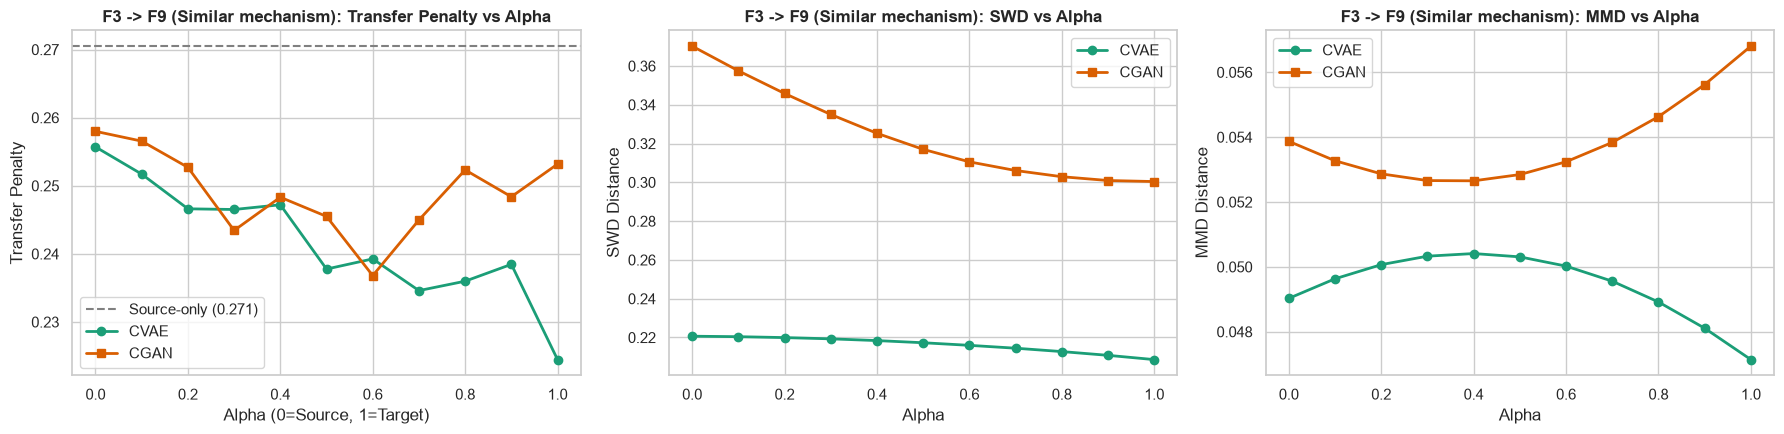


Processing Pair: F5 -> F15 (Same Subsystem)


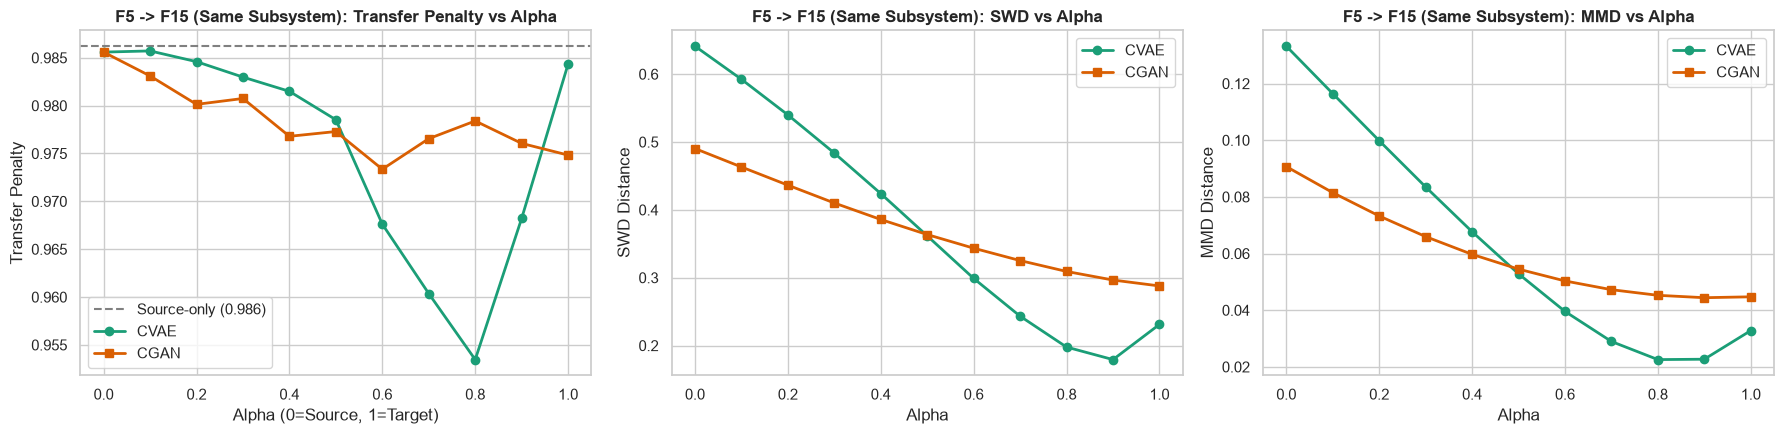


Processing Pair: F4 -> F13 (Unrelated Mechanism)


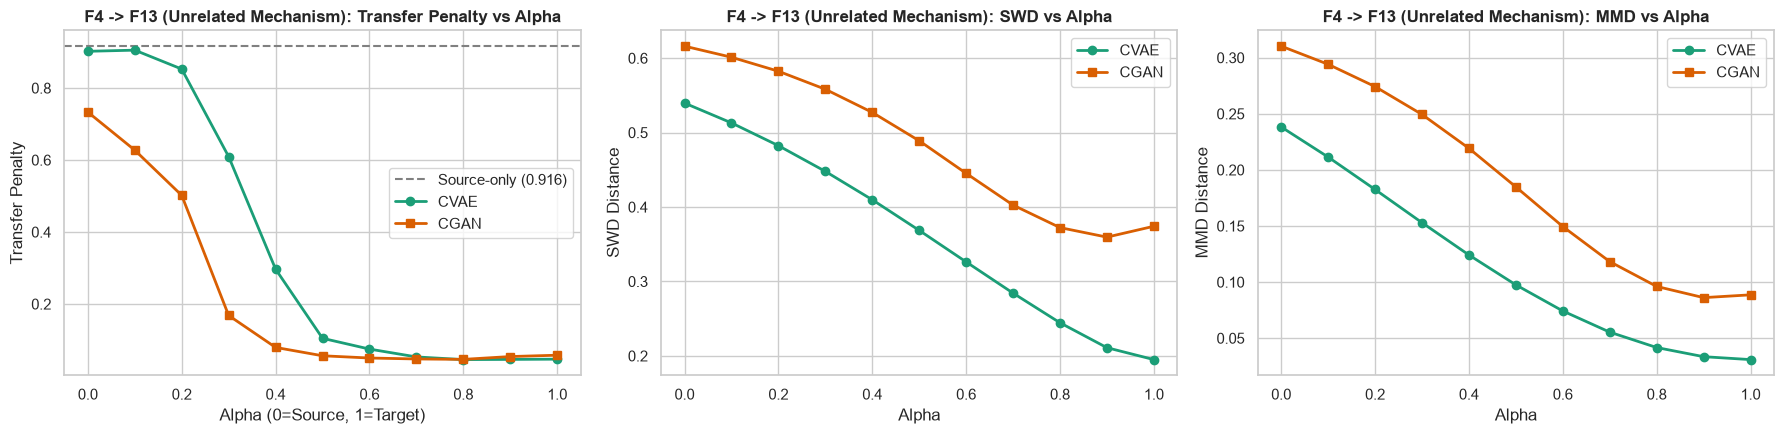


Processing Pair: F6 -> F15 (Unrelated mechanism)


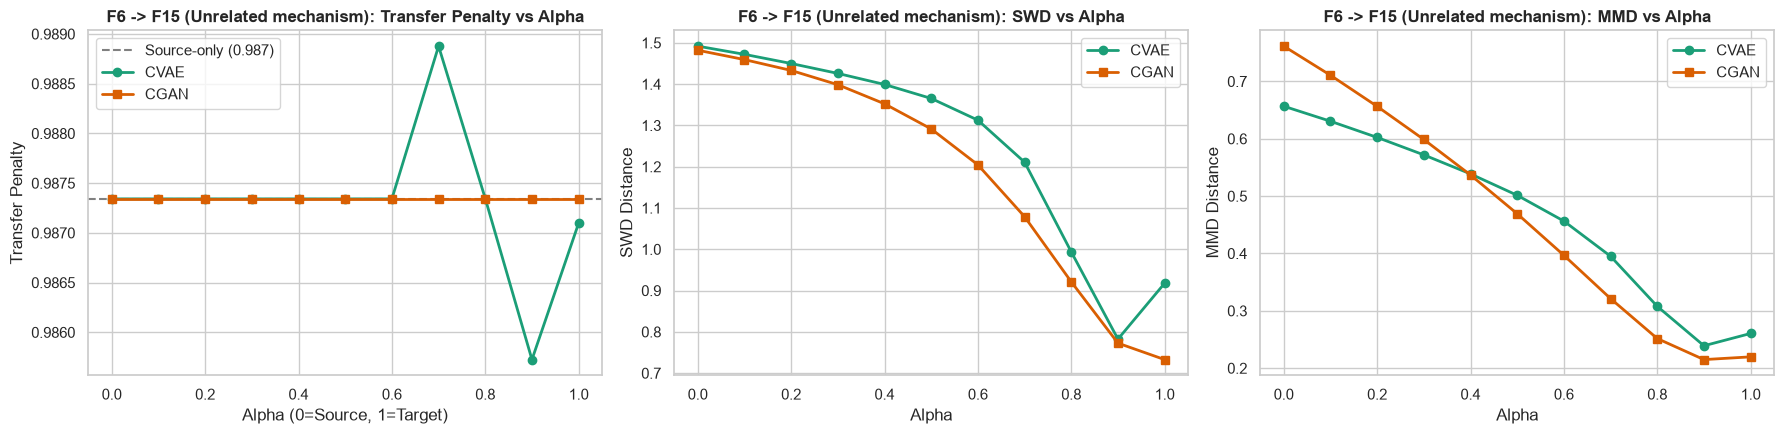

In [37]:
alphas = np.linspace(0.0, 1.0, 11)
N_SYNTHETIC = 500

for pair in REFERENCE_PAIRS:
    pair_name = pair['name']
    src_id = pair['source'][0] if isinstance(pair['source'], list) else pair['source']
    tgt_id = pair['target']
    print(f"\nProcessing Pair: {pair_name}")

    src_anom_tr = DOMAIN_FEATURES[src_id]['train']
    tgt_anom_tr = DOMAIN_FEATURES[tgt_id]['train']
    X_src_norm_tr = DOMAIN_FEATURES[0]['train']
    
    X_src_norm_te = DOMAIN_FEATURES[0]['test']
    src_anom_te = DOMAIN_FEATURES[src_id]['test']
    tgt_anom_te = DOMAIN_FEATURES[tgt_id]['test']
    
    X_source_train = np.vstack([X_src_norm_tr, src_anom_tr])
    y_source_train = np.concatenate([np.zeros(len(X_src_norm_tr)), np.ones(len(src_anom_tr))])


    X_source_test = np.vstack([X_src_norm_te, src_anom_te])
    y_source_test = np.concatenate([np.zeros(len(X_src_norm_te)), np.ones(len(src_anom_te))])
    
    X_tgt_test = np.vstack([X_src_norm_te, tgt_anom_te])
    y_tgt_test = np.concatenate([np.zeros(len(X_src_norm_te)), np.ones(len(tgt_anom_te))])

    all_tr_data = np.vstack([src_anom_tr, tgt_anom_tr])
    scaler = StandardScaler().fit(all_tr_data)
    scaler.scale_ = np.maximum(scaler.scale_, 1e-3)

    X_train_sc = scaler.transform(all_tr_data)
    c_train = np.concatenate([
        np.zeros((len(src_anom_tr), 1), dtype=np.float32),
        np.ones((len(tgt_anom_tr), 1), dtype=np.float32)
    ])

    X_source_train_sc = scaler.transform(X_source_train)
    X_source_test_sc  = scaler.transform(X_source_test)
    X_tgt_test_sc     = scaler.transform(X_tgt_test)
    tgt_scaled        = scaler.transform(tgt_anom_tr)

    set_seed(42)
    cvae = train_cvae(X_train_sc, c_train)
    set_seed(42)
    gen  = train_cgan(X_train_sc, c_train)

    rf0 = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=SEED)
    rf0.fit(X_source_train_sc, y_source_train)
    
    src_baseline_f1 = f1_score(y_source_test, rf0.predict(X_source_test_sc), zero_division=0)
    tgt_baseline_f1 = f1_score(y_tgt_test, rf0.predict(X_tgt_test_sc), zero_division=0)
    noaug_penalty   = src_baseline_f1 - tgt_baseline_f1

    cvae_res, cgan_res = [], []
    for a in alphas:
        with torch.no_grad():
            c_vec = torch.full((N_SYNTHETIC, 1), float(a), device=DEVICE)

            set_seed(SEED)
            z_vec_vae = torch.randn(N_SYNTHETIC, LATENT_DIM, device=DEVICE) * CVAE_TEMPERATURE
            s_vae_sc = cvae.decode(z_vec_vae, c_vec).cpu().numpy()
            
            set_seed(SEED)
            z_vec_gan = torch.randn(N_SYNTHETIC, LATENT_DIM, device=DEVICE)
            s_gan_sc = gen(z_vec_gan, c_vec).cpu().numpy()

        for syn_sc, res_list in [(s_vae_sc, cvae_res), (s_gan_sc, cgan_res)]:
            X_bridged = np.vstack([X_source_train_sc, syn_sc])
            y_bridged = np.concatenate([y_source_train, np.ones(len(syn_sc))])
            
            rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=SEED)
            rf.fit(X_bridged, y_bridged)
            
            bl_f1 = f1_score(y_source_test, rf.predict(X_source_test_sc), zero_division=0)
            tr_f1 = f1_score(y_tgt_test, rf.predict(X_tgt_test_sc), zero_division=0)
            
            dist = compute_distances(scaler.inverse_transform(syn_sc), tgt_anom_tr)
            res_list.append({
                'Alpha': round(a, 2),
                'Penalty': bl_f1 - tr_f1,
                'SWD': dist['SWD'],
                'MMD': dist['MMD'],
                'FD': dist['FD']
            })

    df_v = pd.DataFrame(cvae_res)
    df_g = pd.DataFrame(cgan_res)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
    axes[0].axhline(noaug_penalty, color='gray', ls='--', lw=1.5, label=f'Source-only ({noaug_penalty:.3f})')
    axes[0].plot(df_v['Alpha'], df_v['Penalty'], 'o-', color='#1b9e77', lw=2, label='CVAE')
    axes[0].plot(df_g['Alpha'], df_g['Penalty'], 's-', color='#d95f02', lw=2, label='CGAN')
    axes[0].set_title(f'{pair_name}: Transfer Penalty vs Alpha', fontweight='bold')
    axes[0].set_xlabel('Alpha (0=Source, 1=Target)')
    axes[0].set_ylabel('Transfer Penalty')
    axes[0].legend()

    axes[1].plot(df_v['Alpha'], df_v['SWD'], 'o-', color='#1b9e77', lw=2, label='CVAE')
    axes[1].plot(df_g['Alpha'], df_g['SWD'], 's-', color='#d95f02', lw=2, label='CGAN')
    axes[1].set_title(f'{pair_name}: SWD vs Alpha', fontweight='bold')
    axes[1].set_xlabel('Alpha')
    axes[1].set_ylabel('SWD Distance')
    axes[1].legend()

    axes[2].plot(df_v['Alpha'], df_v['MMD'], 'o-', color='#1b9e77', lw=2, label='CVAE')
    axes[2].plot(df_g['Alpha'], df_g['MMD'], 's-', color='#d95f02', lw=2, label='CGAN')
    axes[2].set_title(f'{pair_name}: MMD vs Alpha', fontweight='bold')
    axes[2].set_xlabel('Alpha')
    axes[2].set_ylabel('MMD Distance')
    axes[2].legend()

    plt.tight_layout()
    plt.show()



Latent Space Evolution (All 208 Features): F3 -> F9 (Similar mechanism)


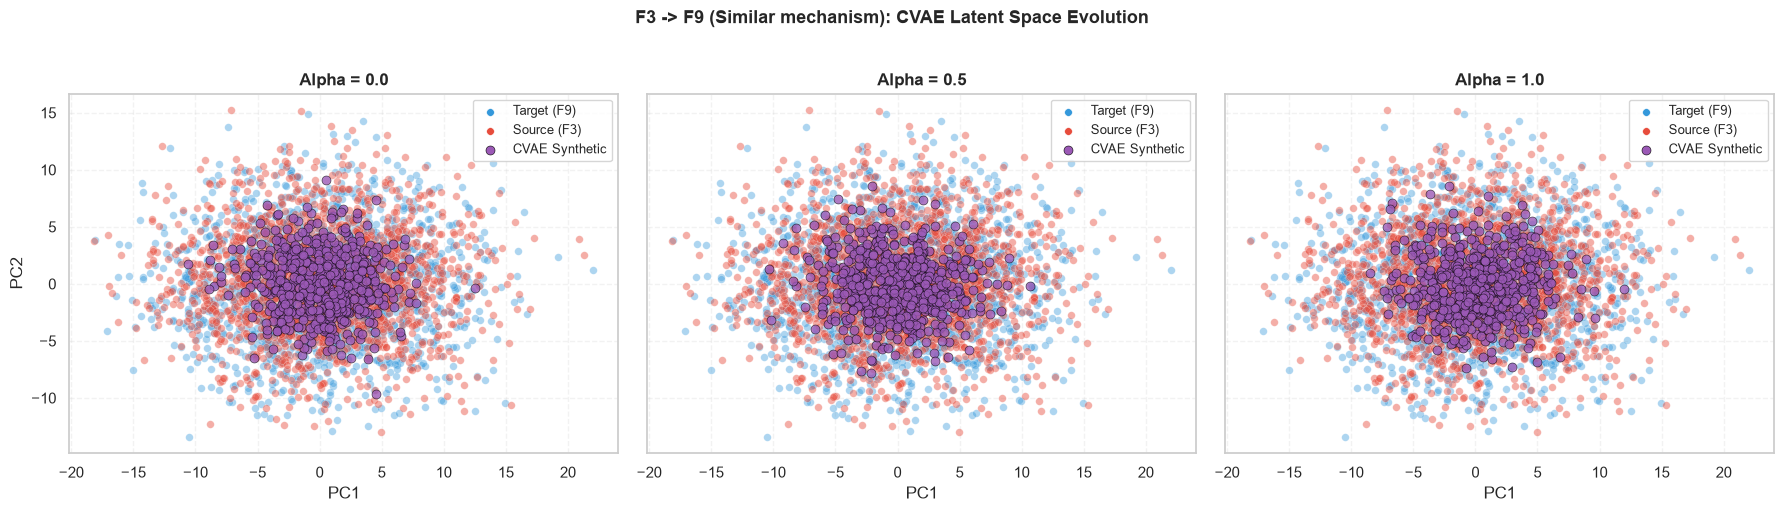

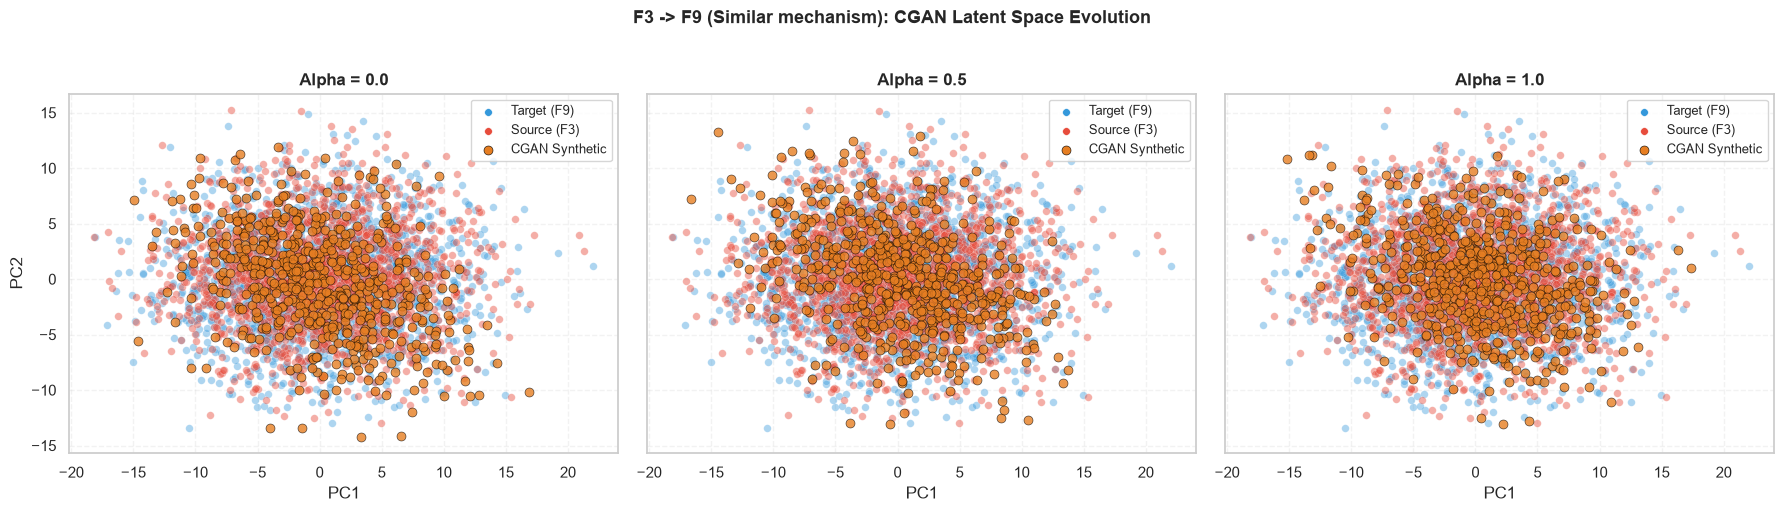


Latent Space Evolution (All 208 Features): F5 -> F15 (Same Subsystem)


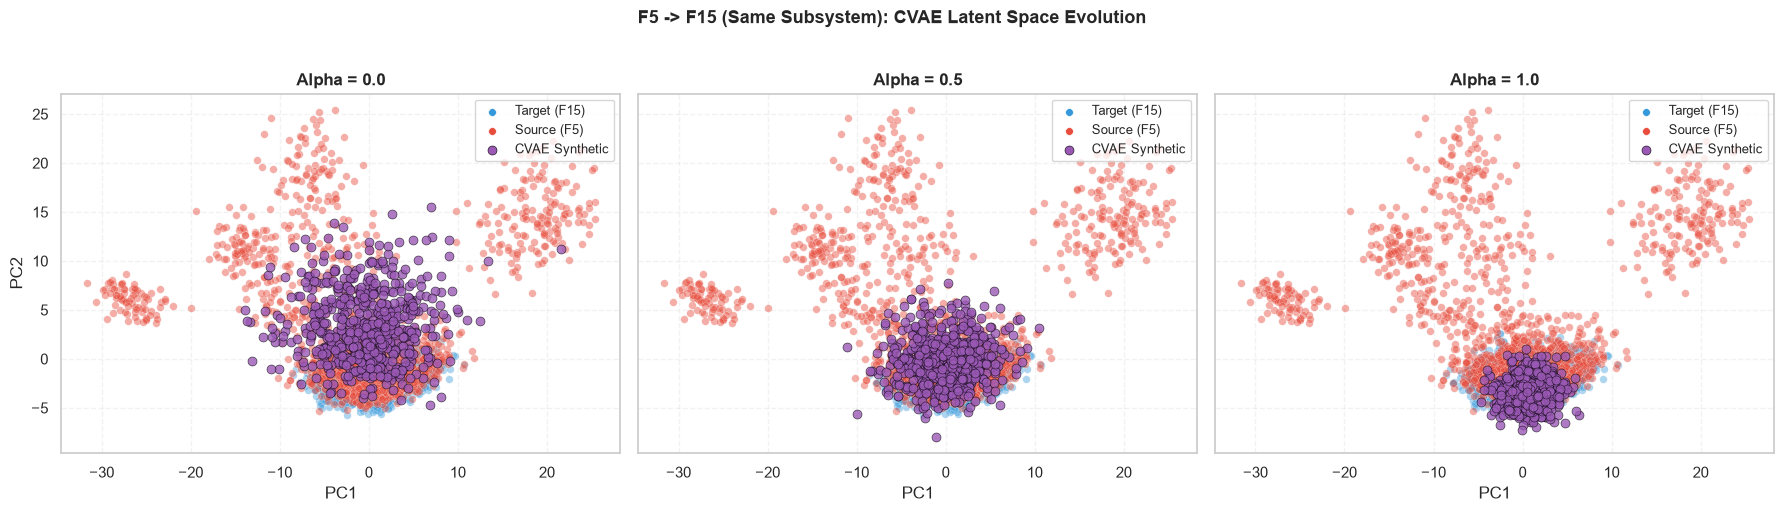

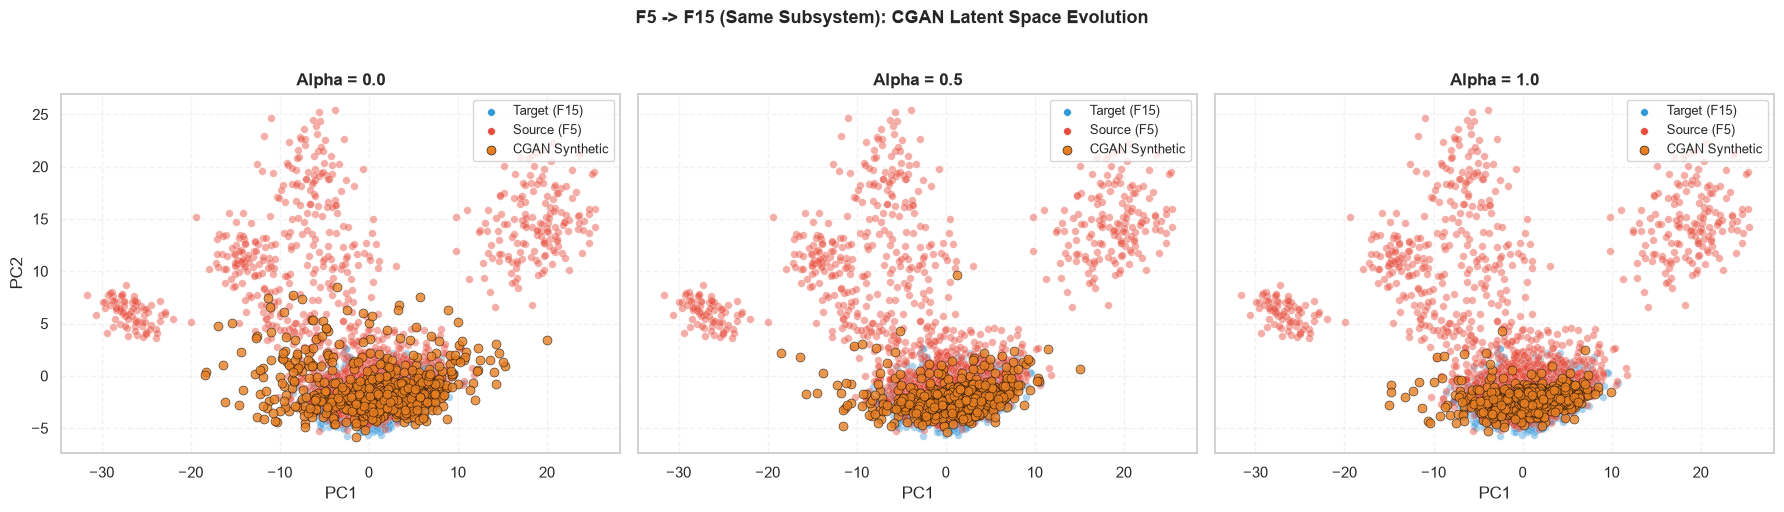


Latent Space Evolution (All 208 Features): F4 -> F13 (Unrelated Mechanism)


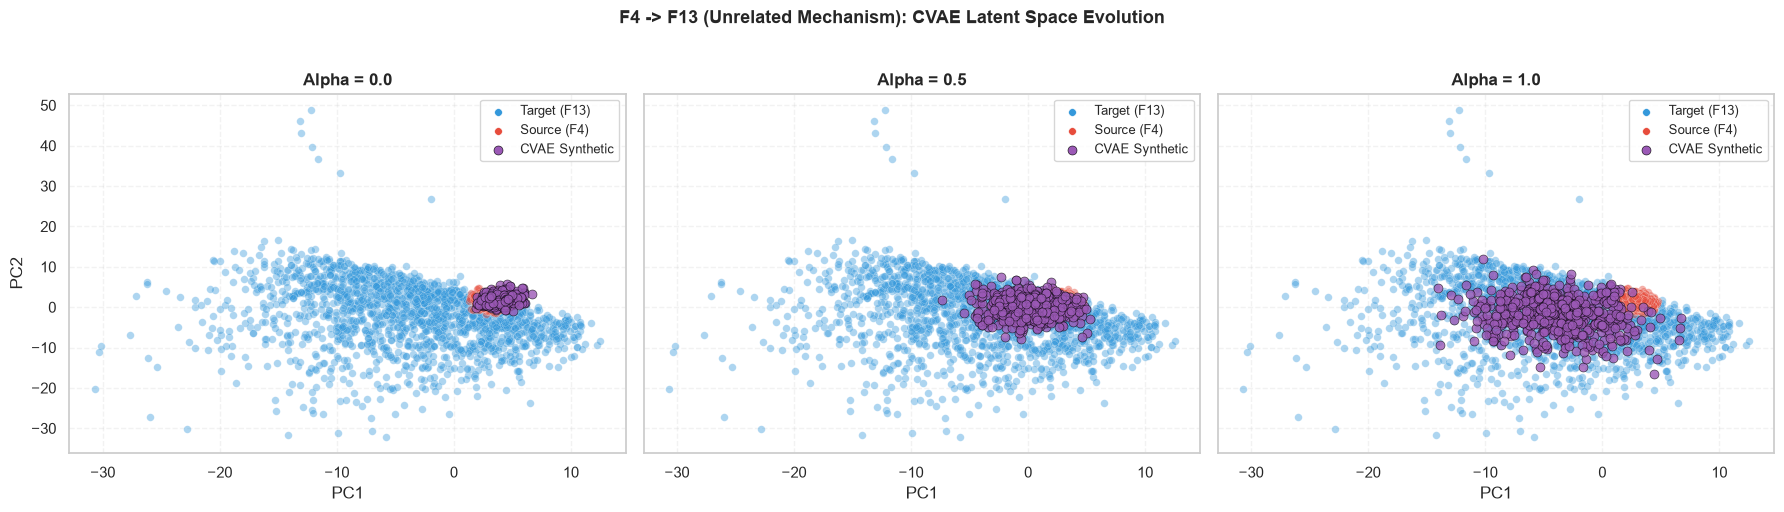

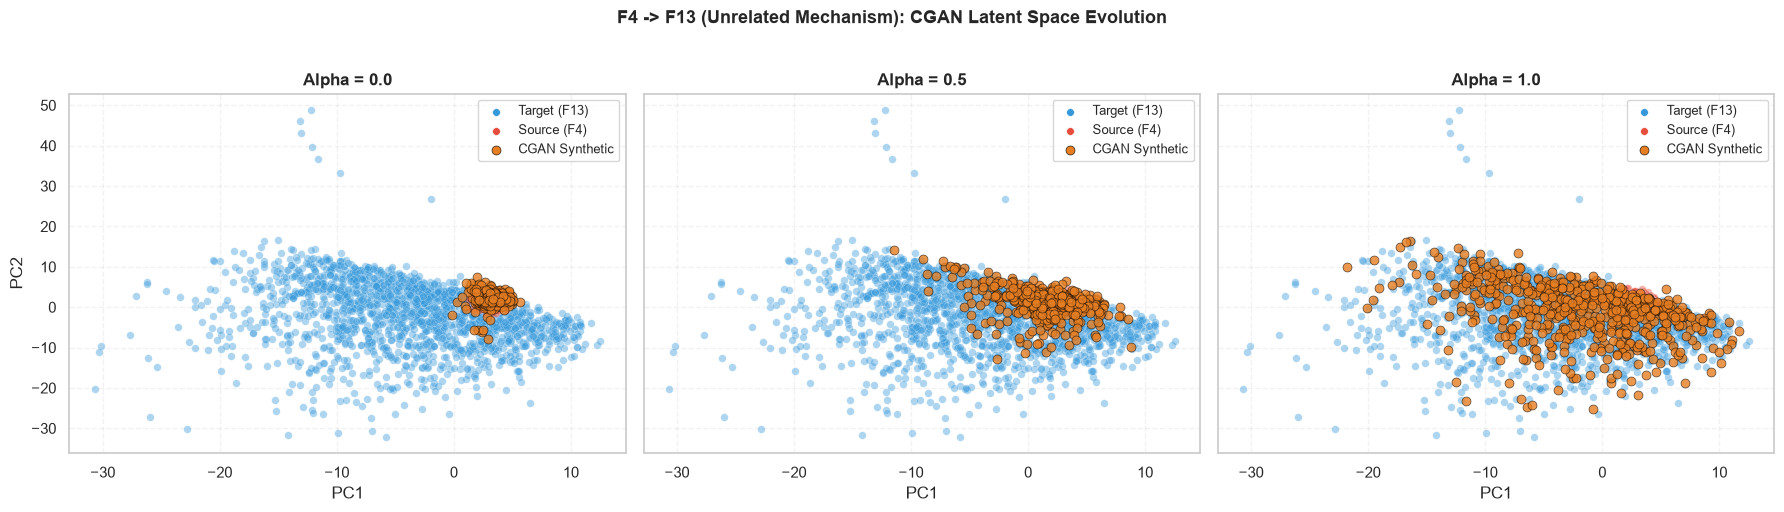


Latent Space Evolution (All 208 Features): F6 -> F15 (Unrelated mechanism)


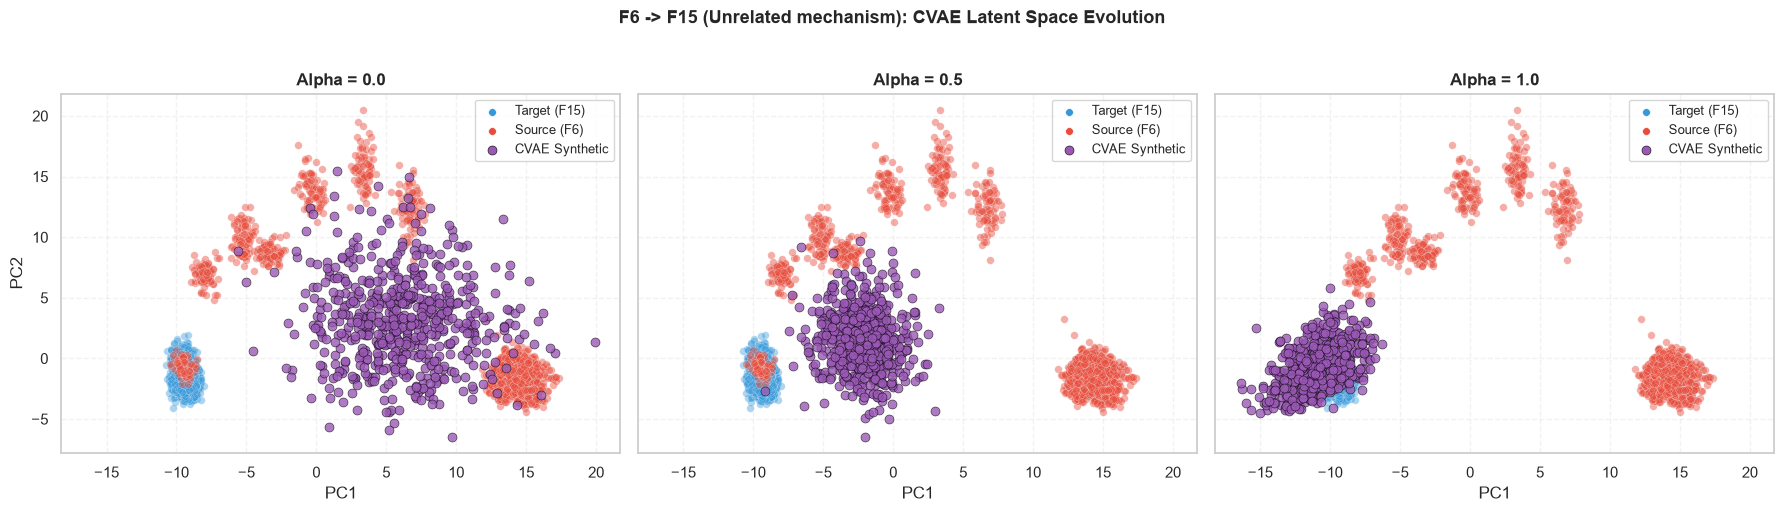

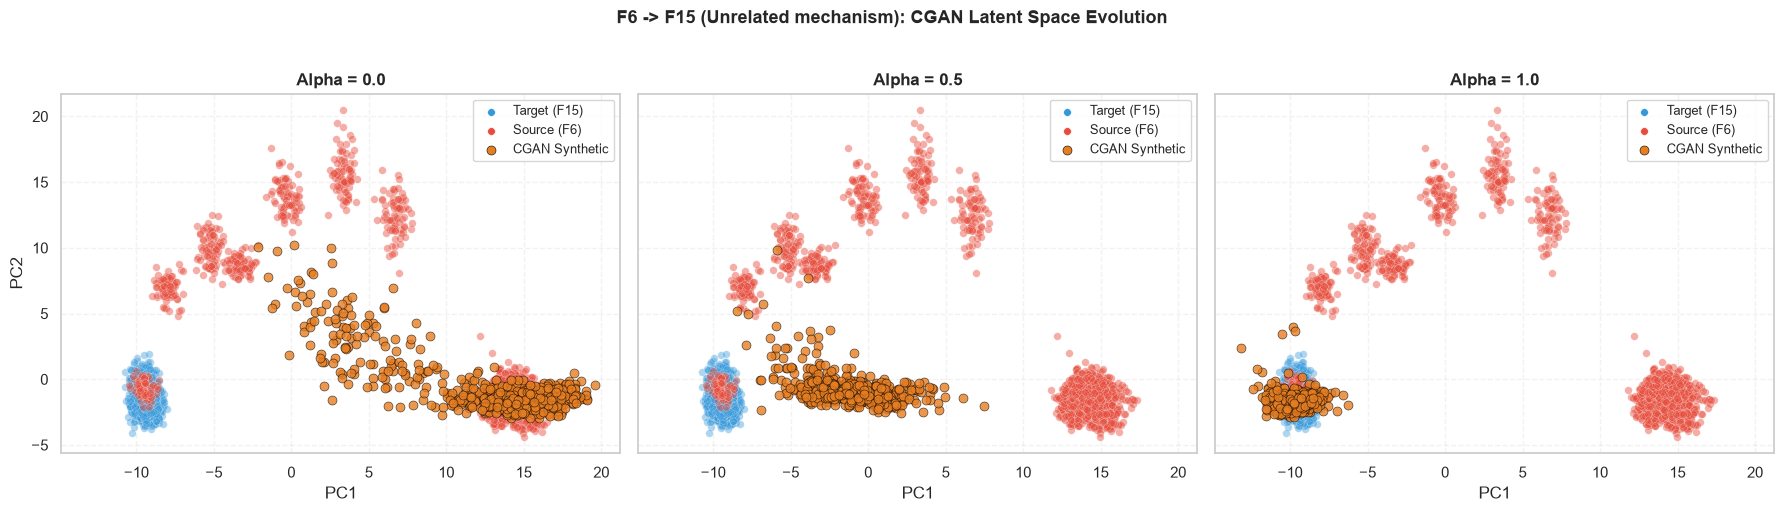

In [38]:
selected_alphas = [0.0, 0.5, 1.0]
COLOR_SRC, COLOR_TGT = '#e74c3c', '#3498db'
COLOR_CVAE, COLOR_CGAN = '#9b59b6', '#e67e22'


for pair in REFERENCE_PAIRS:
    pair_name = pair['name']
    src_id = pair['source'][0] if isinstance(pair['source'], list) else pair['source']
    tgt_id = pair['target']
    print(f"\nLatent Space Evolution (All 208 Features): {pair_name}")
    
    src_anom = DOMAIN_FEATURES[src_id]['train']
    tgt_anom = DOMAIN_FEATURES[tgt_id]['train']
    
    all_tr_data = np.vstack([src_anom, tgt_anom])
    scaler = StandardScaler().fit(all_tr_data)
    scaler.scale_ = np.maximum(scaler.scale_, 1e-3)
    
    X_train_sc = scaler.transform(all_tr_data)
    c_train = np.concatenate([
        np.zeros((len(src_anom), 1), dtype=np.float32),
        np.ones((len(tgt_anom), 1), dtype=np.float32)
    ])

    set_seed(SEED)
    cvae = train_cvae(X_train_sc, c_train)
    set_seed(SEED)
    gen  = train_cgan(X_train_sc, c_train)

    src_sc = scaler.transform(src_anom)
    tgt_sc = scaler.transform(tgt_anom)
    
    pca = PCA(n_components=2, random_state=SEED).fit(np.vstack([src_sc, tgt_sc]))
    src_2d = pca.transform(src_sc)
    tgt_2d = pca.transform(tgt_sc)

    for model_name, model, col in [('CVAE', cvae, COLOR_CVAE), ('CGAN', gen, COLOR_CGAN)]:
        fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)
        
        for idx, a in enumerate(selected_alphas):
            ax = axes[idx]
            with torch.no_grad():
                set_seed(SEED + idx)
                
                c_vec = torch.full((600, 1), float(a), device=DEVICE)
                temp = CVAE_TEMPERATURE if model_name == 'CVAE' else 1.0
                z_vec = torch.randn(600, LATENT_DIM, device=DEVICE) * temp
                
                syn_sc = model.decode(z_vec, c_vec).cpu().numpy() if model_name == 'CVAE' else model(z_vec, c_vec).cpu().numpy()
            
            syn_sc = np.clip(syn_sc, X_train_sc.min(axis=0) * 1.2, X_train_sc.max(axis=0) * 1.2)

            syn_2d = pca.transform(syn_sc)
            

            ax.scatter(tgt_2d[:, 0], tgt_2d[:, 1], alpha=0.40, c=COLOR_TGT, 
                       label=f'Target (F{tgt_id})', s=30, edgecolors='white', linewidth=0.3, zorder=1)
            
            ax.scatter(src_2d[:, 0], src_2d[:, 1], alpha=0.45, c=COLOR_SRC, 
                       label=f'Source (F{src_id})', s=30, edgecolors='white', linewidth=0.3, zorder=2)
            
            ax.scatter(syn_2d[:, 0], syn_2d[:, 1], alpha=0.80, c=col, 
                       label=f'{model_name} Synthetic', s=42, edgecolor='black', linewidth=0.4, zorder=3)
            
            ax.set_title(f'Alpha = {a}', fontweight='bold')
            ax.set_xlabel('PC1')
            if idx == 0: 
                ax.set_ylabel('PC2')
                
            leg = ax.legend(loc='upper right', fontsize=9)
            for handle in leg.legend_handles:
                handle.set_alpha(1.0)
                
            ax.grid(True, linestyle='--', alpha=0.25)

        plt.suptitle(f'{pair_name}: {model_name} Latent Space Evolution', fontweight='bold', fontsize=13, y=1.02)
        plt.tight_layout()
        plt.show()

This continuous domain interpolation evaluation across the four reference transfer tasks once again confirms that generative domain bridging is heavily dictated by physical subsystem alignment. For mechanistically similar and overlapping faults, such as $F3 \to F9$ and $F5 \to F15$, both SWD and MMD metrics decrease steadily as $\alpha \to 1.0$ for the CVAE, matching the PCA latent space projections. In these aligned regimes, CVAE augmentation drives the transfer penalty down to its lowest levels around $\alpha \approx 0.8$, whereas the CGAN exhibits a relatively flat trajectory or minor variations that fail to capture the optimal bridging manifold as effectively.In contrast, when attempting to bridge mechanically decoupled regimes like $F4 \to F13$, both generative models successfully decrease transfer penalties and geometric distances as $\alpha \to 1.0$, dropping close to zero at the boundary as synthetic samples approach the target domain support. However, in the extreme, fully disconnected failure mode $F6 \to F15$, the transfer penalty remains stubbornly flat near catastrophic ceiling levels ($\approx 0.967\text{--}0.987$) across the entire $\alpha$ sweep. While the CVAE attempts a linear interpolation between source and target clusters, the lack of shared underlying manifold geometry means that intermediate synthetic samples act as out-of-distribution noise rather than viable domain bridges, and the CGAN collapses entirely along the latent space projections without approaching the multimodal target modes.Overall, these results demonstrate that while generative interpolation can successfully bridge gaps when partial overlap or compatibility exists (such as in $F3 \to F9$, $F5 \to F15$, and $F4 \to F13$), neither architecture can synthesize a functional decision boundary across completely disjoint, unaligned failure modes like $F6 \to F15$ without genuine target guidance.

## 6. Few-Shot target budget scaling & generative augmentation: 4 core pairs

To evaluate whether synthetic generation can mitigate transfer penalties under limited target data availability, we implement a multi-volume few-shot augmentation protocol. For each of the reference domain pairs, we extract expanding target adaptation budgets representing fractions of the available training data (`TARGET_PERCENT_GRID = [2%, 6%, 12%, 20%]`), yielding $N$ real target samples. 

We benchmark the performance across seven distinct comparative scenarios: a source-only unaugmented baseline, a real-data few-shot baseline ($+N$ real target samples), and multi-volume synthetic expansions using both CVAE and CGAN generators at three scaling multipliers ($1\times, 5\times, \text{and } 10\times N$ synthetic samples). To ensure absolute evaluation integrity and avoid target domain leakage during preprocessing, the StandardScaler is fitted exclusively on the source training dataset (X_source_train). All target evaluation splits, target budget samples, and generated synthetic data are subsequently transformed using these fixed source distribution statistics. Furthermore, each generated batch is clipped within physical boundaries derived from the training margins and inverse-scaled back to raw feature space to prevent out-of-distribution distortion, tracking simultaneous metrics on Transfer Penalty (F1 drop) and distribution divergence ($\text{SWD}, \text{MMD}, \text{FD}$).

In [24]:

def eval_binary_rf(X_aug_raw: np.ndarray, y_aug: np.ndarray,
                   X_src_test_raw: np.ndarray, y_src_test: np.ndarray,
                   X_tgt_test_raw: np.ndarray, y_tgt_test: np.ndarray, fixed_scaler: StandardScaler = None,
                   fixed_baseline_f1: float = None) -> tuple[float, float, float]:
    """Evaluate Random Forest classifier on augmented domain features with exact Stage 2 parity.

    Fits a StandardScaler ONCE on the full training set (X_aug_raw) and transforms
    both the official source test split and frozen target test split.

    Args:
        X_aug_raw (np.ndarray): Augmented raw feature matrix (100% of train data).
        y_aug (np.ndarray): Augmented binary anomaly labels.
        X_src_test_raw (np.ndarray): Official held-out source test split.
        y_src_test (np.ndarray): Official source test labels.
        X_tgt_test_raw (np.ndarray): Frozen target test split.
        y_tgt_test (np.ndarray): Frozen target test labels.
        fixed_scaler (StandardScaler, optional): Pre-fitted StandardScaler. If None, fits on X_aug_raw.

    Returns:
        tuple[float, float, float]: Baseline F1, Transfer F1, and Transfer Penalty.
    """
   
    if fixed_scaler is None:
        fixed_scaler = StandardScaler().fit(X_aug_raw)
    X_tr_sc = fixed_scaler.transform(X_aug_raw)
    X_src_te_sc = fixed_scaler.transform(X_src_test_raw)
    X_tgt_te_sc = fixed_scaler.transform(X_tgt_test_raw)
    
    rf = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
    rf.fit(X_tr_sc, y_aug)
    
    bl_f1 = f1_score(y_src_test, rf.predict(X_src_te_sc), zero_division=0)
    tr_f1 = f1_score(y_tgt_test, rf.predict(X_tgt_te_sc), zero_division=0)
    
    # CORREZIONE: Se fornito, usa l'F1 fisso del modello Source-Only iniziale
    baseline_ref = fixed_baseline_f1 if fixed_baseline_f1 is not None else bl_f1
    penalty = baseline_ref - tr_f1
    return bl_f1, tr_f1, penalty

In [43]:
TARGET_PERCENT_GRID = [0.02, 0.06, 0.12, 0.20]

binary_budget_records = []

for pair in REFERENCE_PAIRS:
    pair_name = pair['name']
    src_id = pair['source'][0] if isinstance(pair['source'], list) else pair['source']
    tgt_id = pair['target']

    print(f"Pair = {pair_name},  Category = {pair['category']}")

    src_anom_tr = DOMAIN_FEATURES[src_id]['train']
    tgt_anom_tr = DOMAIN_FEATURES[tgt_id]['train']
    X_src_norm_tr = DOMAIN_FEATURES[0]['train']

    X_src_norm_te = DOMAIN_FEATURES[0]['test']
    src_anom_te = DOMAIN_FEATURES[src_id]['test']
    tgt_anom_te = DOMAIN_FEATURES[tgt_id]['test']

    X_source_train = np.vstack([X_src_norm_tr, src_anom_tr])
    y_source_train = np.concatenate([np.zeros(len(X_src_norm_tr)), np.ones(len(src_anom_tr))])

    X_source_test = np.vstack([X_src_norm_te, src_anom_te])
    y_source_test = np.concatenate([np.zeros(len(X_src_norm_te)), np.ones(len(src_anom_te))])

    X_tgt_test = np.vstack([X_src_norm_te, tgt_anom_te])
    y_tgt_test = np.concatenate([np.zeros(len(X_src_norm_te)), np.ones(len(tgt_anom_te))])


    fixed_scaler = StandardScaler().fit(X_source_train)
    fixed_scaler.scale_ = np.maximum(fixed_scaler.scale_, 1e-3)
    
    pre_dist = compute_distances(src_anom_tr, tgt_anom_tr)
    

    _, tr_src, pen_src = eval_binary_rf(
        X_source_train,
        y_source_train,
        X_source_test,
        y_source_test,
        X_tgt_test,
        y_tgt_test,
        fixed_scaler=fixed_scaler
    )
  
    for pct in TARGET_PERCENT_GRID:
        total_tgt_train = len(tgt_anom_tr)
        N = max(10, int(np.round(pct * total_tgt_train)))
        set_seed(SEED)
        rng = np.random.default_rng(SEED)
        idx = rng.choice(total_tgt_train, N, replace=False)
        tgt_budget_anom = tgt_anom_tr[idx]

        X_real_raw = np.vstack([X_source_train, tgt_budget_anom])
        y_real = np.concatenate([y_source_train, np.ones(N)])
        _, tr_real, pen_real = eval_binary_rf(
        X_real_raw,
        y_real,
        X_source_test,
        y_source_test,
        X_tgt_test,
        y_tgt_test,
        fixed_scaler=fixed_scaler,
        fixed_baseline_f1=tr_src 
    )
        dist_real = compute_distances(tgt_budget_anom, tgt_anom_tr)


        sub_tr_data = np.vstack([src_anom_tr, tgt_budget_anom])
        sub_scaler = StandardScaler().fit(sub_tr_data)
        sub_scaler.scale_ = np.maximum(sub_scaler.scale_, 1e-3)

        X_sub_tr_sc = sub_scaler.transform(sub_tr_data)
        c_sub_tr = np.concatenate([
            np.zeros((len(src_anom_tr), 1), dtype=np.float32),
            np.ones((len(tgt_budget_anom), 1), dtype=np.float32)
        ])

        margin = 0.20 * (sub_tr_data.max(axis=0) - sub_tr_data.min(axis=0))
        lower_bound = sub_scaler.transform((sub_tr_data.min(axis=0) - margin).reshape(1, -1)).squeeze()
        upper_bound = sub_scaler.transform((sub_tr_data.max(axis=0) + margin).reshape(1, -1)).squeeze()

        set_seed(SEED)
        cvae = train_cvae(X_sub_tr_sc, c_sub_tr)
        set_seed(SEED)
        gen  = train_cgan(X_sub_tr_sc, c_sub_tr)

        # Multi-Volume Synthetic Generation for CVAE and CGAN (1x N, 5x N, 10x N)
        syn_dict_raw = {}
        for model_name, model_obj in [('CVAE', cvae), ('CGAN', gen)]:
            for mult in [1, 5, 10]:
                n_gen = mult * N
                with torch.no_grad():
                    set_seed(SEED + mult)
                    c_vec = torch.ones((n_gen, 1), device=DEVICE)

                    if model_name == 'CVAE':
                        z_vec = torch.randn(n_gen, LATENT_DIM, device=DEVICE) * CVAE_TEMPERATURE
                        syn_sc = cvae.decode(z_vec, c_vec).cpu().numpy()
                    else:
                        z_vec = torch.randn(n_gen, LATENT_DIM, device=DEVICE)
                        syn_sc = model_obj(z_vec, c_vec).cpu().numpy()

                    syn_sc = np.clip(syn_sc, lower_bound, upper_bound)
                    syn_dict_raw[f'{model_name}_{mult}x'] = sub_scaler.inverse_transform(syn_sc)

        # Generative Evaluation Scenarios (CVAE 1x, 5x, 10x and CGAN 1x, 5x, 10x)
        eval_gen_res = {}
        for key, syn_raw in syn_dict_raw.items():
            X_bridged_raw = np.vstack([X_source_train, syn_raw])
            y_bridged = np.concatenate([y_source_train, np.ones(len(syn_raw))])

            _, tr_f1, pen = eval_binary_rf(
                X_bridged_raw,
                y_bridged,
                X_source_test,
                y_source_test,
                X_tgt_test,
                y_tgt_test,
                fixed_scaler=fixed_scaler,
                fixed_baseline_f1=tr_src ,
            )
            dist = compute_distances(syn_raw, tgt_anom_tr)

            eval_gen_res[key] = {
                'tr_f1': tr_f1, 'penalty': pen,
                'SWD': dist['SWD'], 'MMD': dist['MMD'], 'FD': dist['FD']
            }

        binary_budget_records.append({
            'Pair': pair_name, 'Category': pair['category'], 'Percent': pct * 100, 'N': N,
            'Pre_SWD': pre_dist['SWD'], 'Pre_MMD': pre_dist['MMD'], 'Pre_FD': pre_dist['FD'],

            # Scenario 1: Source only
            'F1_Source_Only': tr_src, 'Penalty_Source_Only': pen_src,

            # Scenario 2: Real N
            'F1_Real_N': tr_real, 'Penalty_Real_N': pen_real, 'SWD_Real_N': dist_real['SWD'], 'MMD_Real_N': dist_real['MMD'], 'FD_Real_N': dist_real['FD'],

            # CVAE Multi-Volume
            'F1_CVAE_1x': eval_gen_res['CVAE_1x']['tr_f1'], 'Penalty_CVAE_1x': eval_gen_res['CVAE_1x']['penalty'], 'SWD_CVAE_1x': eval_gen_res['CVAE_1x']['SWD'], 'MMD_CVAE_1x': eval_gen_res['CVAE_1x']['MMD'], 'FD_CVAE_1x': eval_gen_res['CVAE_1x']['FD'],
            'F1_CVAE_5x': eval_gen_res['CVAE_5x']['tr_f1'], 'Penalty_CVAE_5x': eval_gen_res['CVAE_5x']['penalty'], 'SWD_CVAE_5x': eval_gen_res['CVAE_5x']['SWD'], 'MMD_CVAE_5x': eval_gen_res['CVAE_5x']['MMD'], 'FD_CVAE_5x': eval_gen_res['CVAE_5x']['FD'],
            'F1_CVAE_10x': eval_gen_res['CVAE_10x']['tr_f1'], 'Penalty_CVAE_10x': eval_gen_res['CVAE_10x']['penalty'], 'SWD_CVAE_10x': eval_gen_res['CVAE_10x']['SWD'], 'MMD_CVAE_10x': eval_gen_res['CVAE_10x']['MMD'], 'FD_CVAE_10x': eval_gen_res['CVAE_10x']['FD'],

            # CGAN Multi-Volume
            'F1_CGAN_1x': eval_gen_res['CGAN_1x']['tr_f1'], 'Penalty_CGAN_1x': eval_gen_res['CGAN_1x']['penalty'], 'SWD_CGAN_1x': eval_gen_res['CGAN_1x']['SWD'], 'MMD_CGAN_1x': eval_gen_res['CGAN_1x']['MMD'], 'FD_CGAN_1x': eval_gen_res['CGAN_1x']['FD'],
            'F1_CGAN_5x': eval_gen_res['CGAN_5x']['tr_f1'], 'Penalty_CGAN_5x': eval_gen_res['CGAN_5x']['penalty'], 'SWD_CGAN_5x': eval_gen_res['CGAN_5x']['SWD'], 'MMD_CGAN_5x': eval_gen_res['CGAN_5x']['MMD'], 'FD_CGAN_5x': eval_gen_res['CGAN_5x']['FD'],
            'F1_CGAN_10x': eval_gen_res['CGAN_10x']['tr_f1'], 'Penalty_CGAN_10x': eval_gen_res['CGAN_10x']['penalty'], 'SWD_CGAN_10x': eval_gen_res['CGAN_10x']['SWD'], 'MMD_CGAN_10x': eval_gen_res['CGAN_10x']['MMD'], 'FD_CGAN_10x': eval_gen_res['CGAN_10x']['FD'],

            'Gain_CVAE_1x': eval_gen_res['CVAE_1x']['tr_f1'] - tr_src,
            'Gain_CVAE_5x': eval_gen_res['CVAE_5x']['tr_f1'] - tr_src,
            'Gain_CVAE_10x': eval_gen_res['CVAE_10x']['tr_f1'] - tr_src,
            'Gain_CGAN_1x': eval_gen_res['CGAN_1x']['tr_f1'] - tr_src,
            'Gain_CGAN_5x': eval_gen_res['CGAN_5x']['tr_f1'] - tr_src,
            'Gain_CGAN_10x': eval_gen_res['CGAN_10x']['tr_f1'] - tr_src,
        })

df_binary_budget = pd.DataFrame(binary_budget_records)

summary_5_scenarios = df_binary_budget.groupby('Percent').agg({
    'N': 'mean',
    'F1_Source_Only': 'mean',
    'F1_Real_N': 'mean',
    'F1_CVAE_1x': 'mean',
    'F1_CVAE_5x': 'mean',
    'F1_CVAE_10x': 'mean',
    'F1_CGAN_1x': 'mean',
    'F1_CGAN_5x': 'mean',
    'F1_CGAN_10x': 'mean',
    'SWD_Real_N': 'mean',
    'SWD_CVAE_1x': 'mean',
    'SWD_CVAE_5x': 'mean',
    'SWD_CVAE_10x': 'mean',
    'SWD_CGAN_1x': 'mean',
    'SWD_CGAN_5x': 'mean',
    'SWD_CGAN_10x': 'mean',
}).reset_index()

display(summary_5_scenarios.round(4))


Pair = F3 -> F9 (Similar mechanism),  Category = Similar mechanism
Pair = F5 -> F15 (Same Subsystem),  Category = Same subsystem, diff. type
Pair = F4 -> F13 (Unrelated Mechanism),  Category = Unrelated mechanism
Pair = F6 -> F15 (Unrelated mechanism),  Category = Unrelated mechanism


,Percent,N,F1_Source_Only,F1_Real_N,F1_CVAE_1x,F1_CVAE_5x,F1_CVAE_10x,F1_CGAN_1x,F1_CGAN_5x,F1_CGAN_10x,SWD_Real_N,SWD_CVAE_1x,SWD_CVAE_5x,SWD_CVAE_10x,SWD_CGAN_1x,SWD_CGAN_5x,SWD_CGAN_10x
0,2.0,38.0,0.1211,0.3316,0.3240,0.3428,0.3526,0.2111,0.3257,0.3192,0.2063,0.8214,0.5563,0.4791,0.9140,0.6614,0.6006
1,6.0,115.0,0.1211,0.3425,0.3373,0.3655,0.3802,0.2883,0.3129,0.3279,0.1137,0.5304,0.3827,0.3403,0.7498,0.5541,0.5239
2,12.0,230.0,0.1211,0.3531,0.3469,0.3848,0.4299,0.3440,0.3580,0.3632,0.0772,0.4724,0.3508,0.3283,0.6295,0.4985,0.4883
3,20.0,384.0,0.1211,0.3693,0.3508,0.3941,0.4396,0.3503,0.3634,0.3681,0.0560,0.3901,0.3162,0.3050,0.5242,0.4449,0.4486


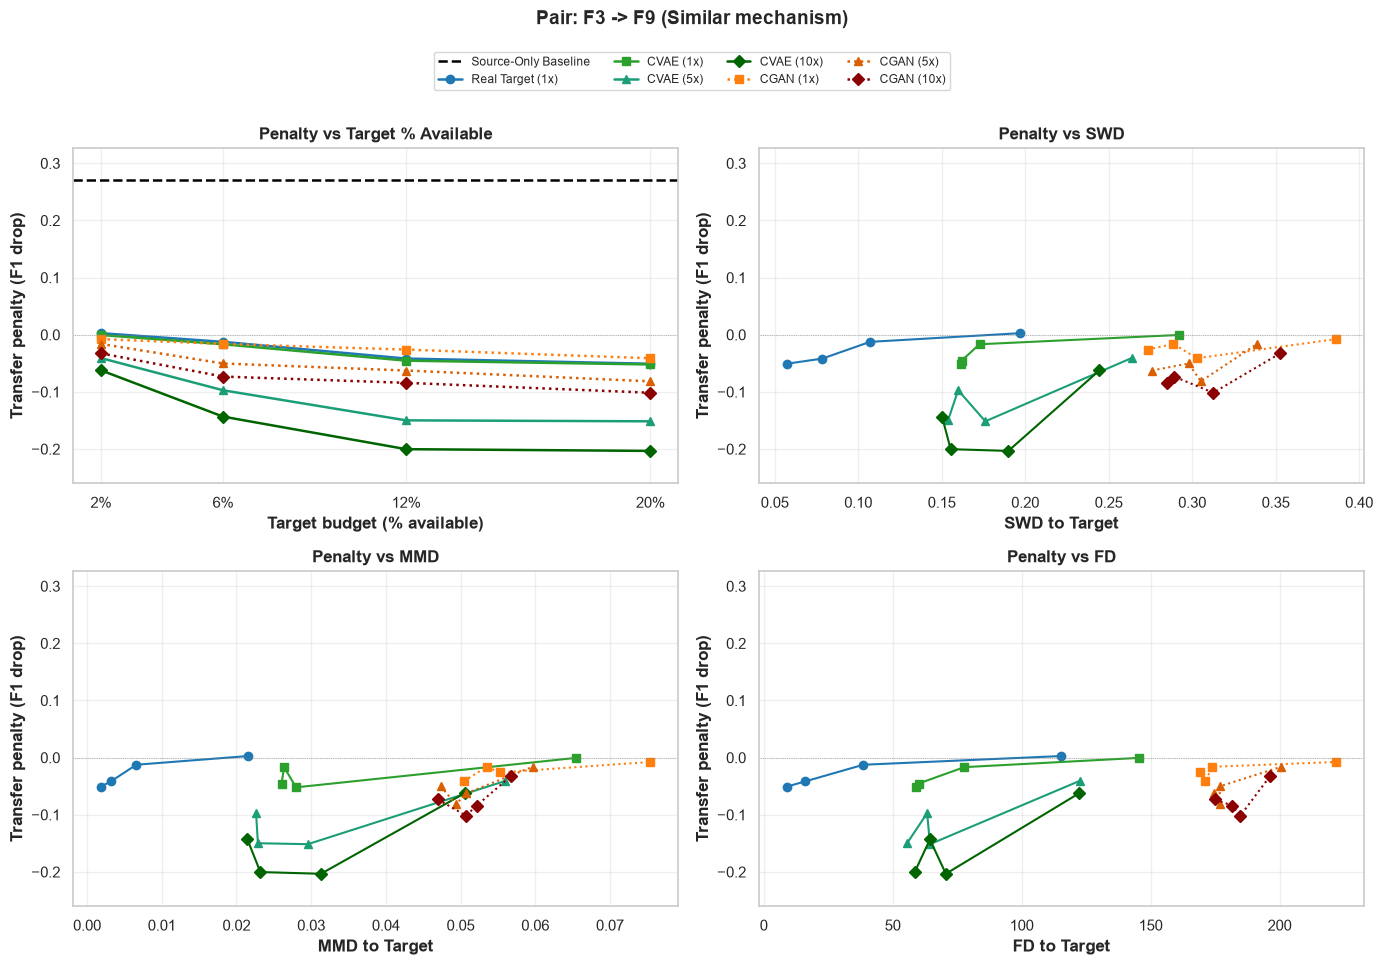

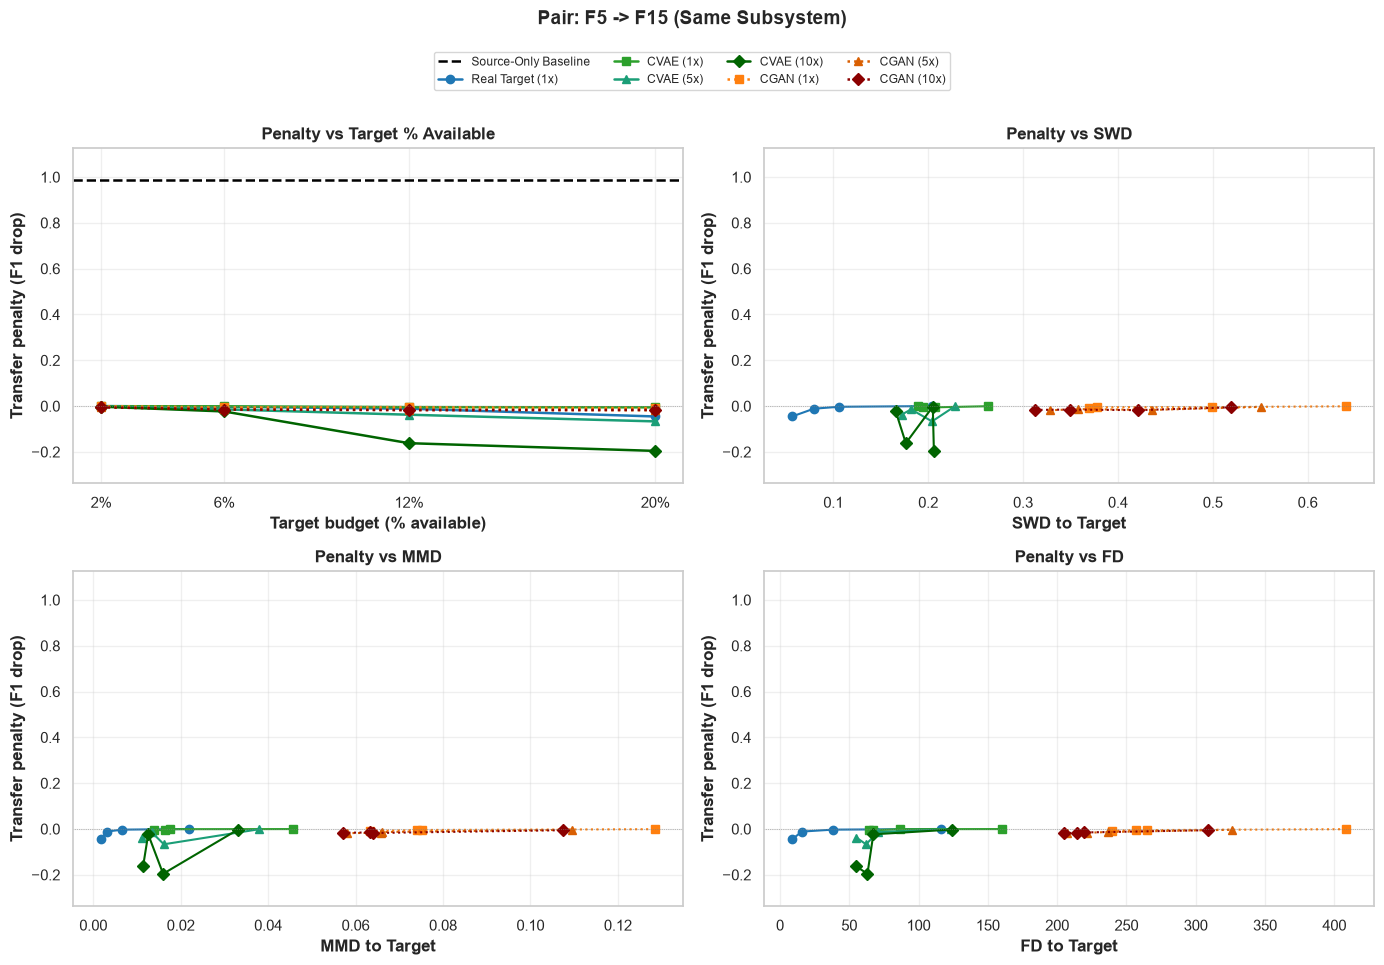

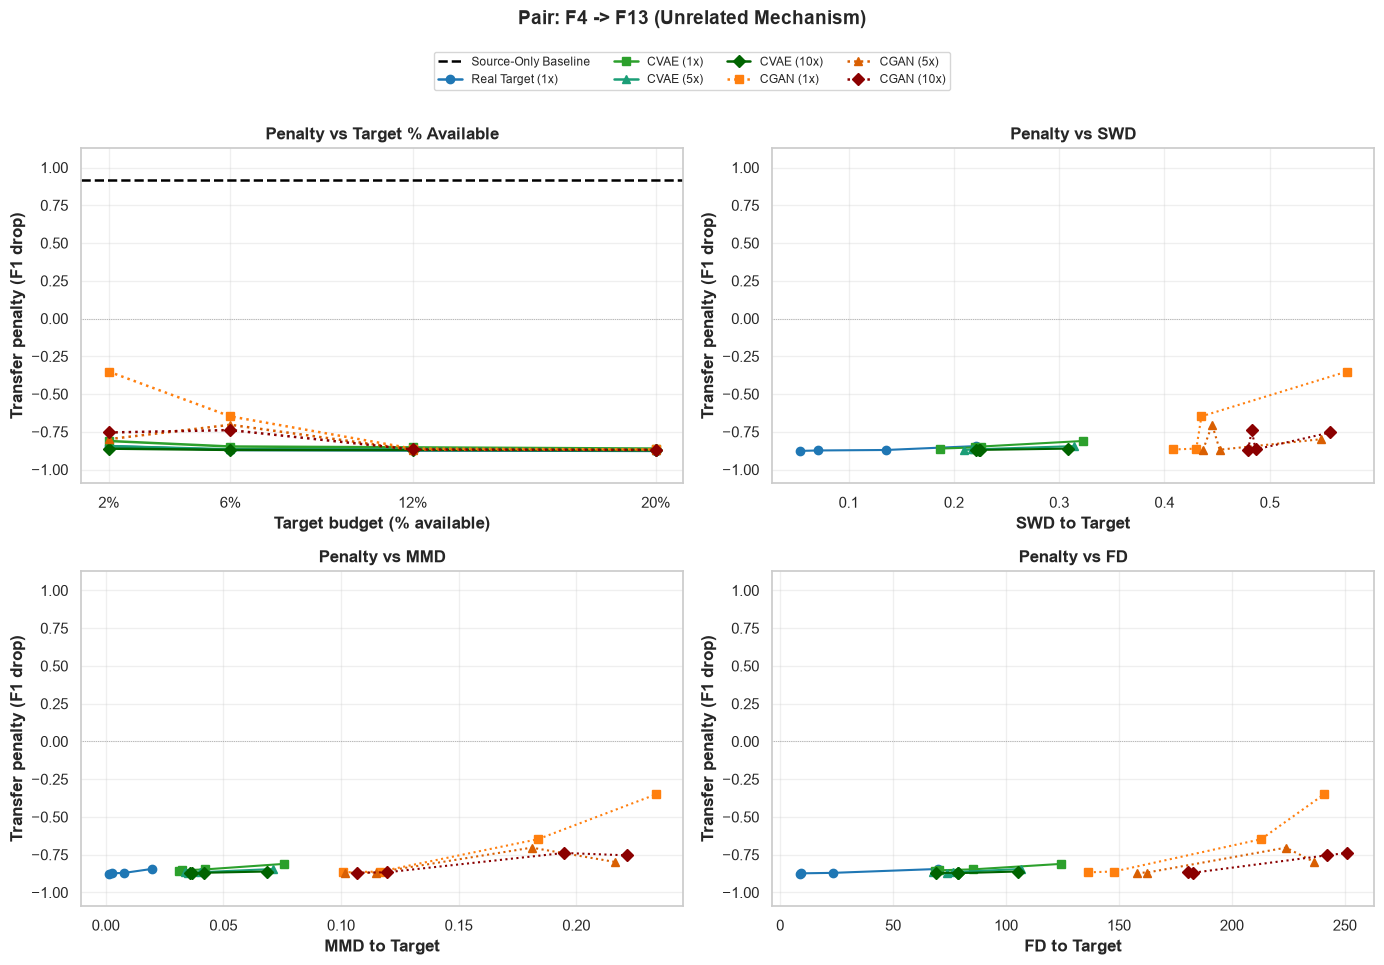

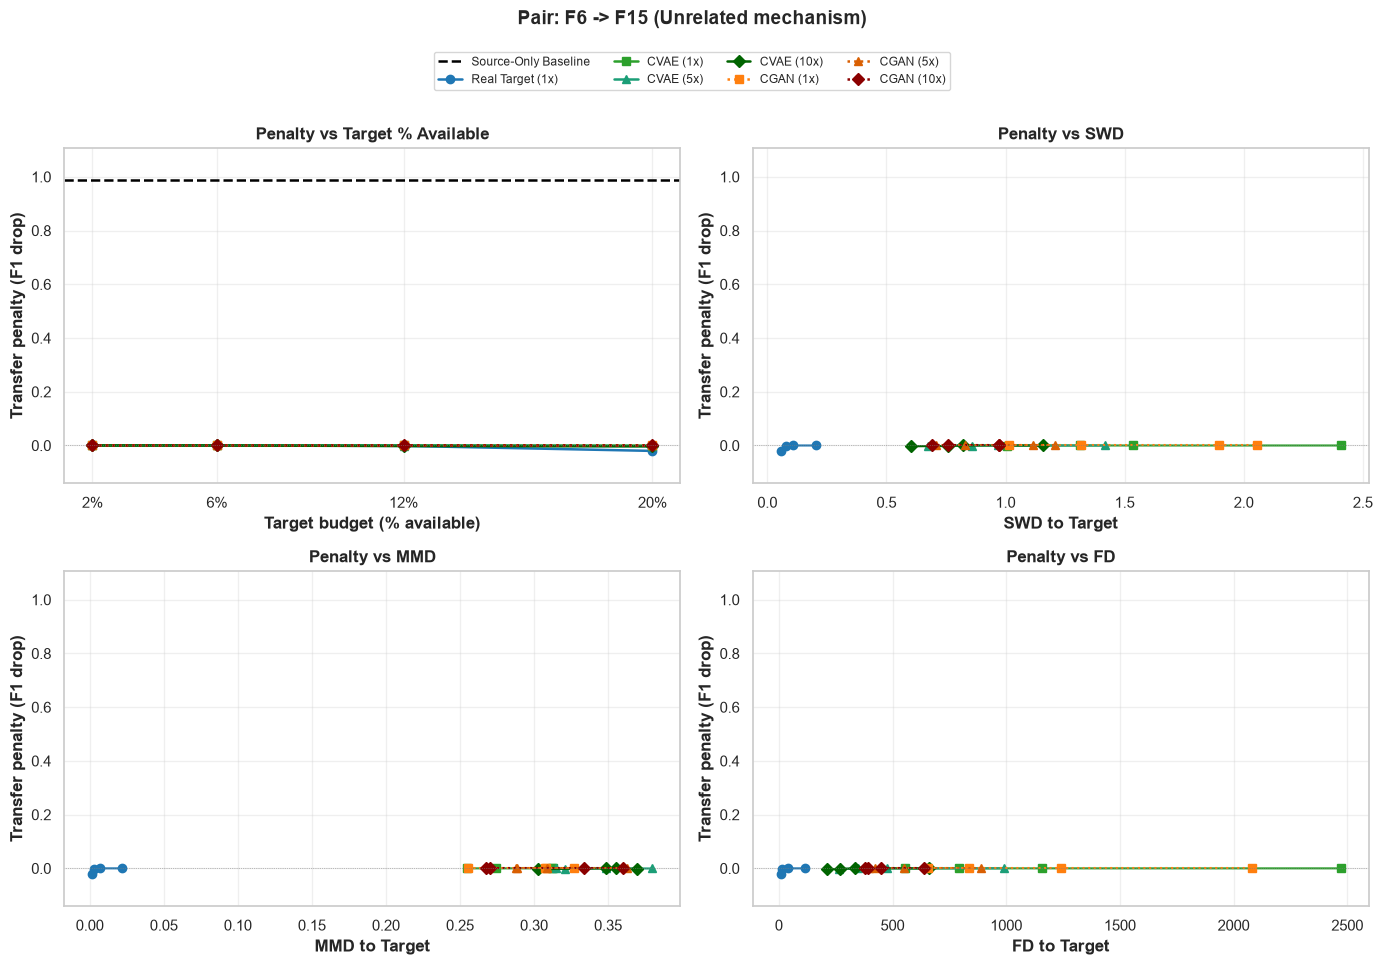

In [44]:
STYLES = {
    'Real_N':    {'color': '#1f77b4', 'ls': '-',  'marker': 'o', 'label': 'Real Target (1x)'},
    'CVAE_1x':   {'color': '#2ca02c', 'ls': '-',  'marker': 's', 'label': 'CVAE (1x)'},
    'CVAE_5x':   {'color': '#1b9e77', 'ls': '-',  'marker': '^', 'label': 'CVAE (5x)'},
    'CVAE_10x':  {'color': '#006400', 'ls': '-',  'marker': 'D', 'label': 'CVAE (10x)'},
    'CGAN_1x':   {'color': '#ff7f0e', 'ls': ':',  'marker': 's', 'label': 'CGAN (1x)'},
    'CGAN_5x':   {'color': '#d95f02', 'ls': ':',  'marker': '^', 'label': 'CGAN (5x)'},
    'CGAN_10x':  {'color': '#8b0000', 'ls': ':',  'marker': 'D', 'label': 'CGAN (10x)'},
}

def plot_distance_panel(ax, tbl, metric_name):
    """Panel for the metrics of distance (SWD, MMD, FD) vs Transfer Penalty."""
    src_pen = tbl['Penalty_Source_Only'].iloc[0]
    
    for scen_key, style in STYLES.items():
        col_dist = f'{metric_name}_{scen_key}'
        col_pen  = f'Penalty_{scen_key}'
        
        if col_dist in tbl.columns and col_pen in tbl.columns:
            s = tbl.sort_values(col_dist)
            ax.plot(s[col_dist], s[col_pen], label=style['label'], color=style['color'], 
                    ls=style['ls'], marker=style['marker'], lw=1.5)

    ax.axhline(0, color='gray', lw=0.5, ls=':')
    ax.set_xlabel(f'{metric_name} to Target', fontweight='bold')
    ax.set_ylabel('Transfer penalty (F1 drop)', fontweight='bold')
    ax.set_title(f'Penalty vs {metric_name}', fontweight='bold')
    ax.grid(True, alpha=0.3)


def plot_pair_budget(pair_name, tbl):
    """Generates a 2x2 grid for a single fault pair."""
    src_pen_val = tbl['Penalty_Source_Only'].iloc[0]
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    ax_pct = axes[0, 0]
    ax_pct.axhline(src_pen_val, color='black', ls='--', lw=1.8, label='Source-Only Baseline')

    for scen_key, style in STYLES.items():
        col_pen = f'Penalty_{scen_key}'
        if col_pen in tbl.columns:
            s = tbl.sort_values('Percent')
            ax_pct.plot(s['Percent'], s[col_pen], label=style['label'], color=style['color'], 
                        ls=style['ls'], marker=style['marker'], lw=1.8)

    ax_pct.axhline(0, color='gray', lw=0.5, ls=':')
    ax_pct.set_xlabel('Target budget (% available)', fontweight='bold')
    ax_pct.set_ylabel('Transfer penalty (F1 drop)', fontweight='bold')
    ax_pct.set_title('Penalty vs Target % Available', fontweight='bold')
    ax_pct.set_xticks([2, 6, 12, 20])
    ax_pct.set_xticklabels(['2%', '6%', '12%', '20%'])
    ax_pct.grid(True, alpha=0.3)

    plot_distance_panel(axes[0, 1], tbl, 'SWD')
    plot_distance_panel(axes[1, 0], tbl, 'MMD')
    plot_distance_panel(axes[1, 1], tbl, 'FD')

    all_pen_cols = [c for c in tbl.columns if c.startswith('Penalty_')]
    y_vals = tbl[all_pen_cols].values.flatten()
    y_vals = y_vals[~np.isnan(y_vals)]
    y_min, y_max = np.min(y_vals), np.max(y_vals)
    pad_y = (y_max - y_min) * 0.12 if y_max != y_min else 0.05
    
    for ax in axes.flat:
        ax.set_ylim(y_min - pad_y, y_max + pad_y)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.03), ncol=4, fontsize=8.5, frameon=True)

    fig.suptitle(f'Pair: {pair_name}', fontsize=14, fontweight='bold', y=1.07)
    plt.tight_layout()
    plt.show()

for pair_name in df_binary_budget['Pair'].unique():
    tbl_pair = df_binary_budget[df_binary_budget['Pair'] == pair_name]
    plot_pair_budget(pair_name, tbl_pair)

By evaluating the few-shot target budget scaling and multi-volume generative augmentation, we demonstrate that expanding the available target data budget from $2\%$ ($N = 38$) to $20\%$ ($N = 384$) systematically enhances classifier adaptability, elevating the target F1 score from a source-only baseline of $0.1211$ up to $0.3693$ under real-only target integration. Across this expansion grid, CVAE-based multi-volume synthetic expansions consistently outperform both real-only few-shot learning and CGAN-based augmentations, with higher synthetic volume multipliers ($10\times$) providing superior regularization against performance degradation.Specifically, at the maximum $20\%$ target budget tier ($N=384$), the CVAE-$10\times$ configuration achieves an average macro F1 score of $0.4396$, markedly surpassing the real-only target baseline at $0.3693$ and the corresponding CGAN-$10\times$ configuration at $0.3681$. Furthermore, distance metrics show that CVAE samples better match the target distribution as volume increases, while CGAN samples remain limited by mode instability and structural compression. Analyzing individual pair dynamics reveals that these performance gains are heavily conditioned on the physical pairing category; physically coupled faults, such as $F3 \to F9$ and $F5 \to F15$, benefit greatly from CVAE augmentation because their shared underlying mechanisms allow the model to smoothly bridge the domain gap. As seen in the PCA projections, similar pairs and same-subsystem transfers naturally share overlapping feature spaces; because their underlying physical regimes are closely aligned, training or fitting on the source domain inherently captures the core structure of the target domain, allowing the CVAE to successfully bridge them with minimal transfer penalty.In contrast, completely unrelated or disjoint faults exhibit fundamentally different distance and behavior. For instance, in unaligned pairs like $F6 \to F15$, distribution divergence metrics scale massively (with SWD exceeding $2.5$), proving that the source and target geometries are fundamentally incompatible. Consequently, the synthetic samples generated by both CVAE and CGAN act as out-of-distribution noise rather than valid bridges, causing the adaptation process to fail entirely for disjoint failure modes regardless of data volume.Adding more real target data naturally helps improve performance (scaling the budget reduces transfer penalties over time). However, combining it with synthetic data only provides extra benefits when the domains share underlying physical compatibility. For coupled pairs (such as $F3 \to F9$), increasing synthetic volume via CVAE (especially in the $10\times$ configuration) effectively reduces divergence and improves adaptation up to an F1 of $0.4396$ at $20\%$ budget. Conversely, for disjoint or unrelated pairs (such as $F6 \to F15$), extreme geometric divergence causes synthetic samples to act merely as out-of-distribution noise: in this scenario, budget expansion yields no benefit, and performance remains severely constrained.

### 7. Binary Budget-Controlled Experiment: 5 Comparative Scenarios (20 Domain Pairs)

In accordance with industrial benchmarking guidelines, for each target sample budget $N \in \{100, 250, 500, 1000\}$, the target test set (`split = 'test'`) is strictly frozen and separated.

We evaluate **5 distinct operational scenarios** across all 20 benchmark domain pairs (for both **CVAE** and **CGAN**):

1. **Scenario 1: Source Only (Stage 2 Baseline)** — Classifier trained exclusively on the source domain.
2. **Scenario 2: Source + Real Target ($+N\text{ real}$)** — Classifier trained on source + limited budget $N$ of real target samples.
3. **Scenario 3: Source + Synthetic $1\times N$ ($+N\text{ synth}$)** — Parity test: checks if synthetic samples provide comparable utility to real measurements at the exact same sample count ($N$).
4. **Scenario 4: Source + Synthetic $5\times N$ ($+5N\text{ synth}$)** — Information amplification test: checks if generative models amplify the sparse $N$ target observations.
5. **Scenario 5: Source + Synthetic $10\times N$ ($+10N\text{ synth}$)** — High-volume amplification test ($10\times N$).

For every scenario, we track:
* **Transfer F1 and Transfer Penalty** ($F1_{\text{baseline}} - F1_{\text{transfer}}$) on the frozen target test set.
* **Distribution Distance to Target (SWD, MMD, FD)** before and after augmentation to test if distance reduction directly yields transfer penalty reduction.


In [22]:
def generate_domain_pairs() -> list[dict]:
    """Generate curated benchmark domain pairs for transfer learning evaluation.

    Returns:
        list[dict]: List of pair configurations specifying source faults, target fault, and category.
    """
    pairs = [
            #  The 6 Core Benchmark Pairs 
            {"source": [3],        "target": 9,   "name": "F3 -> F9",             "category": "Similar mechanism"},          # (Feed D: Step -> Random)
            {"source": [5],        "target": 15,  "name": "F5 -> F15",            "category": "Same subsystem, diff. type"}, # (Condenser: Step temp -> Valve stiction)
            {"source": [14],       "target": 15,  "name": "F14 -> F15",           "category": "Similar mechanism"},          # (Valves: Reactor sticking -> Condenser sticking)
            {"source": [4],        "target": 14,  "name": "F4 -> F14",            "category": "Same subsystem, diff. type"}, # (Reactor: Step temp -> Valve stiction)
            {"source": [4],        "target": 13,  "name": "F4 -> F13",            "category": "Unrelated mechanism"},        # (Thermal step -> Reaction kinetics drift)
            {"source": [6],        "target": 15,  "name": "F6 -> F15",            "category": "Unrelated mechanism"},        # (Feed A loss step -> Condenser valve stiction)
    
            #  Additional Similar Mechanism (Low SWD / High Dynamic Alignment) 
            {"source": [9],        "target": 15,  "name": "F9 -> F15",            "category": "Similar mechanism"},          # (Absolute plant minimum distance)
            {"source": [11],       "target": 12,  "name": "F11 -> F12",           "category": "Similar mechanism"},          # Twin heat exchangers: Reactor temp random -> Condenser temp random
            {"source": [10],       "target": 16,  "name": "F10 -> F16",           "category": "Similar mechanism"},          # (Feed C random -> Unknown 16 manifold)
            {"source": [11],       "target": 14,  "name": "F11 -> F14",           "category": "Similar mechanism"},          # (Cooling loop correlation)
    
            #  Additional Same Subsystem, Diff. Type (Direct Physical Unit Counterparts) 
            {"source": [4],        "target": 11,  "name": "F4 -> F11",            "category": "Same subsystem, diff. type"}, # (Reactor: Step temp -> Random temp)
            {"source": [5],        "target": 12,  "name": "F5 -> F12",            "category": "Same subsystem, diff. type"}, # (Condenser: Step temp -> Random temp)
            {"source": [12],       "target": 15,  "name": "F12 -> F15",           "category": "Same subsystem, diff. type"}, # (Condenser: Random temp -> Valve stiction)
            {"source": [1],        "target": 8,   "name": "F1 -> F8",             "category": "Same subsystem, diff. type"}, # (Feed ratio/comp: Step -> Random)
    
            #  Additional Unrelated Mechanism (Global Heatmap Isolators and Decoupled Loops) 
            {"source": [7],        "target": 14,  "name": "F7 -> F14",            "category": "Unrelated mechanism"},        # Decoupled units: Header C pressure loss -> Reactor cooling valve
            {"source": [4],        "target": 18,  "name": "F4 -> F18",            "category": "Unrelated mechanism"},        # (Reactor temp step -> Unknown 18 isolator)
            {"source": [1],        "target": 13,  "name": "F1 -> F13",            "category": "Unrelated mechanism"},        # (Feed step -> Reaction kinetics drift)
    
            #  Many-to-One: Coherent Groups (Shared Manifold and Common Target Sinks) 
            {"source": [3, 4],     "target": 9,   "name": "(F3,F4) -> F9",        "category": "Coherent group"},             # Sources cluster closely around F9 
            {"source": [1, 2],     "target": 8,   "name": "(F1,F2) -> F8",        "category": "Coherent group"},             # Feed mass conservation (A/C ratio + B stream) -> Multicomponent disturbance
    
            #  Many-to-One: Control Groups (Orthogonal Sources vs Unrelated Target) 
            {"source": [1, 6],     "target": 15,  "name": "(F1,F6) -> F15",       "category": "Control group"},              # Feed composition + feed loss targeting condenser valve
        ]
    return pairs
    
SELECTED_PAIRS = generate_domain_pairs()
pd.DataFrame(SELECTED_PAIRS)[["name", "source", "target", "category"]]


TARGET_PERCENT_GRID = [0.02, 0.06, 0.12, 0.20]






In [25]:

binary_budget_records = []

for pair in tqdm(SELECTED_PAIRS, desc='Evaluating 20 Domain Pairs'):
    set_seed(SEED)
    rng = np.random.default_rng(SEED)
    
    print(f'\n\nPAIR = {pair["name"]} | PAIR CATEGORY = {pair["category"]}')
    src_faults = pair['source'] if isinstance(pair['source'], list) else [pair['source']]
    tgt_fault  = pair['target']
    
    X_src_norm_tr = DOMAIN_FEATURES[0]['train']
    src_anom_combined = np.vstack([DOMAIN_FEATURES[f]['train'] for f in src_faults])
    X_src = np.vstack([X_src_norm_tr, src_anom_combined])
    y_src = np.concatenate([np.zeros(len(X_src_norm_tr)), np.ones(len(src_anom_combined))])
    
    X_src_norm_te = DOMAIN_FEATURES[0]['test']
    src_anom_combined_te = np.vstack([DOMAIN_FEATURES[f]['test'] for f in src_faults])
    X_src_test = np.vstack([X_src_norm_te, src_anom_combined_te])
    y_src_test = np.concatenate([np.zeros(len(X_src_norm_te)), np.ones(len(src_anom_combined_te))])

    X_tgt_test = np.vstack([X_src_norm_te, DOMAIN_FEATURES[tgt_fault]['test']])
    y_tgt_test = np.concatenate([np.zeros(len(X_src_norm_te)), np.ones(len(DOMAIN_FEATURES[tgt_fault]['test']))])

    X_tgt_train_anom  = DOMAIN_FEATURES[tgt_fault]['train']
    total_tgt_train   = len(X_tgt_train_anom)

 
    
    # Scenario 1: Source-only Baseline (raw feature space, matching Stage 2)
    fixed_scaler = StandardScaler().fit(X_src)
    fixed_scaler.scale_ = np.maximum(fixed_scaler.scale_, 1e-3)
    pre_dist = compute_distances(src_anom_combined, X_tgt_train_anom)
    _, tr_src, pen_src = eval_binary_rf(
        X_src,
        y_src,
        X_src_test,
        y_src_test,
        X_tgt_test,
        y_tgt_test,
        fixed_scaler=fixed_scaler,
    )
    print(f'Scenario 1 - Source-only Baseline | Target F1: {tr_src:.4f} | Penalty: {pen_src:.4f} | SWD: {pre_dist["SWD"]:.4f} | MMD: {pre_dist["MMD"]:.4f} | FD: {pre_dist["FD"]:.4f}')
    
    for pct in TARGET_PERCENT_GRID:
        N = max(10, int(np.round(pct * total_tgt_train)))
        print(f'\n{N} samples ({pct*100:.0f}%)')

        idx = rng.choice(total_tgt_train, N, replace=False)
        tgt_budget_anom = X_tgt_train_anom[idx]
        
         # Scenario 2: Source + Real Target 
        X_real_raw = np.vstack([X_src, tgt_budget_anom])
        y_real = np.concatenate([y_src, np.ones(N)])
        _, tr_real, pen_real = eval_binary_rf(
            X_real_raw,
            y_real,
            X_src_test,
            y_src_test,
            X_tgt_test,
            y_tgt_test,
            fixed_scaler=fixed_scaler,
            fixed_baseline_f1=tr_src
        )
        dist_real = compute_distances(tgt_budget_anom, X_tgt_train_anom)

        print(f'Scenario 2 - Source + {N} Real Target (1x) | Target F1: {tr_real:.4f} | Penalty: {pen_real:.4f} | SWD: {dist_real["SWD"]:.4f} | MMD: {dist_real["MMD"]:.4f} | FD: {dist_real["FD"]:.4f}')
        
        sub_tr_data = np.vstack([src_anom_combined, tgt_budget_anom])
        sub_scaler = StandardScaler().fit(sub_tr_data)
        sub_scaler.scale_ = np.maximum(sub_scaler.scale_, 1e-3)

        X_sub_tr_sc = sub_scaler.transform(sub_tr_data)
        c_sub_tr = np.concatenate([
            np.zeros((len(src_anom_combined), 1), dtype=np.float32),
            np.ones((len(tgt_budget_anom), 1), dtype=np.float32)
        ])

        margin = 0.20 * (sub_tr_data.max(axis=0) - sub_tr_data.min(axis=0))
        lower_bound = sub_scaler.transform((sub_tr_data.min(axis=0) - margin).reshape(1, -1)).squeeze()
        upper_bound = sub_scaler.transform((sub_tr_data.max(axis=0) + margin).reshape(1, -1)).squeeze()

        set_seed(SEED)
        m_vae = train_cvae(X_sub_tr_sc, c_sub_tr, epochs=50, beta=1e-5)
        
        with torch.no_grad():
            set_seed(SEED + 1)
            c1 = torch.ones((N, 1), device=DEVICE)
            zv1 = torch.randn(N, LATENT_DIM, device=DEVICE) * CVAE_TEMPERATURE
            syn_v1 = m_vae.decode(zv1, c1).cpu().numpy()
            syn_v1 = np.clip(syn_v1, lower_bound, upper_bound)
            
            set_seed(SEED + 5)
            c5 = torch.ones((5 * N, 1), device=DEVICE)
            zv5 = torch.randn(5 * N, LATENT_DIM, device=DEVICE) * CVAE_TEMPERATURE
            syn_v5 = m_vae.decode(zv5, c5).cpu().numpy()
            syn_v5 = np.clip(syn_v5, lower_bound, upper_bound)
            
            set_seed(SEED + 10)
            c10 = torch.ones((10 * N, 1), device=DEVICE)
            zv10 = torch.randn(10 * N, LATENT_DIM, device=DEVICE) * CVAE_TEMPERATURE
            syn_v10 = m_vae.decode(zv10, c10).cpu().numpy()
            syn_v10 = np.clip(syn_v10, lower_bound, upper_bound)

        syn_v1_raw  = sub_scaler.inverse_transform(syn_v1)
        syn_v5_raw  = sub_scaler.inverse_transform(syn_v5)
        syn_v10_raw = sub_scaler.inverse_transform(syn_v10)

        # Scenario 3: Source + Synthetic 1x N (Parity check vs Real N)
        _, tr_v1, pen_v1 = eval_binary_rf(
            np.vstack([X_src, syn_v1_raw]),
            np.concatenate([y_src, np.ones(N)]),
            X_src_test,
            y_src_test,
            X_tgt_test,
            y_tgt_test,
            fixed_scaler=fixed_scaler,
            fixed_baseline_f1=tr_src
        )
        dist_v1 = compute_distances(syn_v1_raw, X_tgt_train_anom)
        print(f'Scenario 3 - Source + {N} Synthetic (1x) | Target F1: {tr_v1:.4f} | Penalty: {pen_v1:.4f} | SWD: {dist_v1["SWD"]:.4f} | MMD: {dist_v1["MMD"]:.4f} | FD: {dist_v1["FD"]:.4f}')
        
        # Scenario 4: Source + Synthetic 5x N (Information Amplification)
        _, tr_v5, pen_v5 = eval_binary_rf(
            np.vstack([X_src, syn_v5_raw]),
            np.concatenate([y_src, np.ones(5 * N)]),
            X_src_test,
            y_src_test,
            X_tgt_test,
            y_tgt_test,
            fixed_scaler=fixed_scaler,
            fixed_baseline_f1=tr_src
        )
        dist_v5 = compute_distances(syn_v5_raw, X_tgt_train_anom)
        print(f'Scenario 4 - Source + {5 * N} Synthetic (5x) | Target F1: {tr_v5:.4f} | Penalty: {pen_v5:.4f} | SWD: {dist_v5["SWD"]:.4f} | MMD: {dist_v5["MMD"]:.4f} | FD: {dist_v5["FD"]:.4f}')
        
        # Scenario 5: Source + Synthetic 10x N (High-volume Amplification)
        _, tr_v10, pen_v10 = eval_binary_rf(
        np.vstack([X_src, syn_v10_raw]),
            np.concatenate([y_src, np.ones(10 * N)]),
            X_src_test,
            y_src_test,
            X_tgt_test,
            y_tgt_test,
            fixed_scaler=fixed_scaler,
            fixed_baseline_f1=tr_src
        )
        dist_v10 = compute_distances(syn_v10_raw, X_tgt_train_anom)
        print(f'Scenario 5 - Source + {10 * N} Synthetic (10x) | Target F1: {tr_v10:.4f} | Penalty: {pen_v10:.4f} | SWD: {dist_v10["SWD"]:.4f} | MMD: {dist_v10["MMD"]:.4f} | FD: {dist_v10["FD"]:.4f}')
        
        binary_budget_records.append({
            'Pair': pair['name'], 'Category': pair['category'], 'Percent': pct * 100, 'N': N,
            'Pre_SWD': pre_dist['SWD'], 'Pre_MMD': pre_dist['MMD'], 'Pre_FD': pre_dist['FD'],
            # Scenario 1: Source only
            'F1_Source_Only': tr_src, 'Penalty_Source_Only': pen_src,
            # Scenario 2: Real N
            'F1_Real_N': tr_real, 'Penalty_Real_N': pen_real, 'SWD_Real_N': dist_real['SWD'], 'MMD_Real_N': dist_real['MMD'], 'FD_Real_N': dist_real['FD'],
            # Scenario 3: Synth 1x N (Parity)
            'F1_CVAE_1x': tr_v1, 'Penalty_CVAE_1x': pen_v1, 'SWD_CVAE_1x': dist_v1['SWD'], 'MMD_CVAE_1x': dist_v1['MMD'], 'FD_CVAE_1x': dist_v1['FD'],
            # Scenario 4: Synth 5x N (Amplification)
            'F1_CVAE_5x': tr_v5, 'Penalty_CVAE_5x': pen_v5, 'SWD_CVAE_5x': dist_v5['SWD'], 'MMD_CVAE_5x': dist_v5['MMD'], 'FD_CVAE_5x': dist_v5['FD'],
            # Scenario 5: Synth 10x N (Amplification)
            'F1_CVAE_10x': tr_v10, 'Penalty_CVAE_10x': pen_v10, 'SWD_CVAE_10x': dist_v10['SWD'], 'MMD_CVAE_10x': dist_v10['MMD'], 'FD_CVAE_10x': dist_v10['FD'],

            'Gain_CVAE_1x': tr_v1 - tr_src,
            'Gain_CVAE_5x': tr_v5 - tr_src,
            'Gain_CVAE_10x': tr_v10 - tr_src,
        })

df_binary_budget = pd.DataFrame(binary_budget_records)

summary_5_scenarios = df_binary_budget.groupby('Percent').agg({
    'N': 'mean',
    'F1_Source_Only': 'mean',
    'F1_Real_N': 'mean',
    'F1_CVAE_1x': 'mean',
    'F1_CVAE_5x': 'mean',
    'F1_CVAE_10x': 'mean',
    'Pre_SWD': 'mean',
    'Pre_MMD': 'mean',
    'Pre_FD': 'mean',
    'SWD_Real_N': 'mean',
    'MMD_Real_N': 'mean',
    'FD_Real_N': 'mean',
    'SWD_CVAE_1x': 'mean',
    'MMD_CVAE_1x': 'mean',
    'FD_CVAE_1x': 'mean',
    'SWD_CVAE_5x': 'mean',
    'MMD_CVAE_5x': 'mean',
    'FD_CVAE_5x': 'mean',
    'SWD_CVAE_10x': 'mean',
    'MMD_CVAE_10x': 'mean',
    'FD_CVAE_10x': 'mean',
}).reset_index()

print('\n5-Scenario Comparison Table (Averaged across all 20 Pairs)')
display(summary_5_scenarios.round(4))


Evaluating 20 Domain Pairs:   0%|          | 0/20 [00:00<?, ?it/s]



PAIR = F3 -> F9 | PAIR CATEGORY = Similar mechanism
Scenario 1 - Source-only Baseline | Target F1: 0.3994 | Penalty: 0.2704 | SWD: 0.0659 | MMD: 0.0018 | FD: 1.3888

38 samples (2%)
Scenario 2 - Source + 38 Real Target (1x) | Target F1: 0.3967 | Penalty: 0.0027 | SWD: 0.1968 | MMD: 0.0215 | FD: 115.2045
Scenario 3 - Source + 38 Synthetic (1x) | Target F1: 0.3999 | Penalty: -0.0004 | SWD: 0.2919 | MMD: 0.0655 | FD: 145.6542
Scenario 4 - Source + 190 Synthetic (5x) | Target F1: 0.4403 | Penalty: -0.0408 | SWD: 0.2637 | MMD: 0.0560 | FD: 122.4243
Scenario 5 - Source + 380 Synthetic (10x) | Target F1: 0.4616 | Penalty: -0.0622 | SWD: 0.2445 | MMD: 0.0506 | FD: 122.3416

115 samples (6%)
Scenario 2 - Source + 115 Real Target (1x) | Target F1: 0.4142 | Penalty: -0.0148 | SWD: 0.1128 | MMD: 0.0067 | FD: 38.3081
Scenario 3 - Source + 115 Synthetic (1x) | Target F1: 0.4137 | Penalty: -0.0143 | SWD: 0.1860 | MMD: 0.0274 | FD: 76.6204
Scenario 4 - Source + 575 Synthetic (5x) | Target F1: 0.4835

Evaluating 20 Domain Pairs:   5%|▌         | 1/20 [02:45<52:20, 165.29s/it]

Scenario 5 - Source + 3840 Synthetic (10x) | Target F1: 0.6072 | Penalty: -0.2077 | SWD: 0.1789 | MMD: 0.0284 | FD: 66.7719


PAIR = F5 -> F15 | PAIR CATEGORY = Same subsystem, diff. type
Scenario 1 - Source-only Baseline | Target F1: 0.0010 | Penalty: 0.9862 | SWD: 0.4369 | MMD: 0.0825 | FD: 143.5960

38 samples (2%)
Scenario 2 - Source + 38 Real Target (1x) | Target F1: 0.0010 | Penalty: 0.0000 | SWD: 0.2036 | MMD: 0.0219 | FD: 116.4107
Scenario 3 - Source + 38 Synthetic (1x) | Target F1: 0.0015 | Penalty: -0.0005 | SWD: 0.2634 | MMD: 0.0457 | FD: 159.8456
Scenario 4 - Source + 190 Synthetic (5x) | Target F1: 0.0025 | Penalty: -0.0015 | SWD: 0.2280 | MMD: 0.0378 | FD: 123.4105
Scenario 5 - Source + 380 Synthetic (10x) | Target F1: 0.0035 | Penalty: -0.0025 | SWD: 0.2049 | MMD: 0.0331 | FD: 124.2375

115 samples (6%)
Scenario 2 - Source + 115 Real Target (1x) | Target F1: 0.0025 | Penalty: -0.0015 | SWD: 0.1119 | MMD: 0.0067 | FD: 37.8217
Scenario 3 - Source + 115 Synthetic (1x) | Tar

Evaluating 20 Domain Pairs:  10%|█         | 2/20 [04:48<42:10, 140.58s/it]

...

Evaluating 20 Domain Pairs:  95%|█████████▌| 19/20 [42:30<02:55, 175.51s/it]

Scenario 5 - Source + 3840 Synthetic (10x) | Target F1: 0.9753 | Penalty: -0.0405 | SWD: 0.2098 | MMD: 0.0262 | FD: 49.2303


PAIR = (F1,F6) -> F15 | PAIR CATEGORY = Control group
Scenario 1 - Source-only Baseline | Target F1: 0.0000 | Penalty: 0.9873 | SWD: 0.7638 | MMD: 0.3950 | FD: 314.7523

38 samples (2%)
Scenario 2 - Source + 38 Real Target (1x) | Target F1: 0.0000 | Penalty: 0.0000 | SWD: 0.2036 | MMD: 0.0219 | FD: 116.4107
Scenario 3 - Source + 38 Synthetic (1x) | Target F1: 0.0010 | Penalty: -0.0010 | SWD: 0.8706 | MMD: 0.1382 | FD: 568.7223
Scenario 4 - Source + 190 Synthetic (5x) | Target F1: 0.0020 | Penalty: -0.0020 | SWD: 0.7139 | MMD: 0.1311 | FD: 412.5438
Scenario 5 - Source + 380 Synthetic (10x) | Target F1: 0.0070 | Penalty: -0.0070 | SWD: 0.6407 | MMD: 0.1377 | FD: 336.4493

115 samples (6%)
Scenario 2 - Source + 115 Real Target (1x) | Target F1: 0.0000 | Penalty: 0.0000 | SWD: 0.1119 | MMD: 0.0067 | FD: 37.8217
Scenario 3 - Source + 115 Synthetic (1x) | Target F1: 0

Evaluating 20 Domain Pairs: 100%|██████████| 20/20 [46:10<00:00, 138.52s/it]

Scenario 5 - Source + 3840 Synthetic (10x) | Target F1: 0.0372 | Penalty: -0.0372 | SWD: 0.6669 | MMD: 0.2603 | FD: 203.2713

5-Scenario Comparison Table (Averaged across all 20 Pairs)


,Percent,N,F1_Source_Only,F1_Real_N,F1_CVAE_1x,F1_CVAE_5x,F1_CVAE_10x,Pre_SWD,Pre_MMD,Pre_FD,...,FD_Real_N,SWD_CVAE_1x,MMD_CVAE_1x,FD_CVAE_1x,SWD_CVAE_5x,MMD_CVAE_5x,FD_CVAE_5x,SWD_CVAE_10x,MMD_CVAE_10x,FD_CVAE_10x
0,2.0,38.0,0.4961,0.6442,0.6401,0.6493,0.6572,0.4816,0.1933,170.6027,...,96.7216,0.4799,0.0847,314.1830,0.3860,0.0798,195.2309,0.3528,0.0782,168.1596
1,6.0,115.0,0.4961,0.6512,0.6458,0.6603,0.6669,0.4816,0.1933,170.6027,...,31.6506,0.3774,0.0667,186.9615,0.3082,0.0690,116.9443,0.2931,0.0712,103.0025
2,12.0,230.0,0.4961,0.6581,0.6524,0.6700,0.6861,0.4816,0.1933,170.6027,...,14.3496,0.3263,0.0611,141.3180,0.2790,0.0661,96.9156,0.2757,0.0679,92.2647
3,20.0,384.0,0.4961,0.6662,0.6558,0.6768,0.6895,0.4816,0.1933,170.6027,...,7.3833,0.3067,0.0636,121.3807,0.2826,0.0693,94.7862,0.2867,0.0705,94.8731


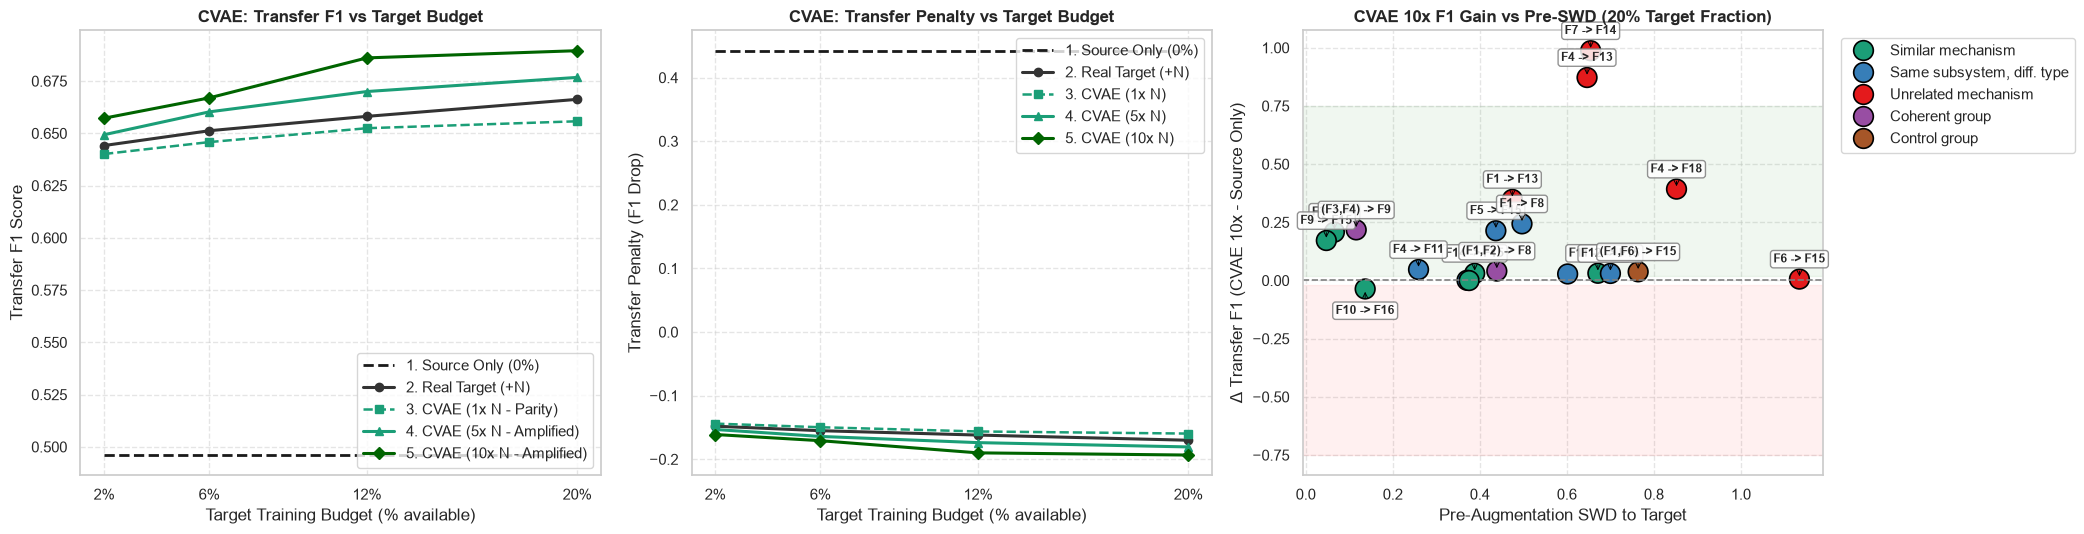

In [26]:

PAIR_CATEGORY_PALETTE = {
        'Similar mechanism': '#1b9e77',
        'Same subsystem, diff. type': '#377eb8',
        'Unrelated mechanism': '#e41a1c',
        'Coherent group': '#984ea3',
        'Control group': '#a65628'
    }
fig, axes = plt.subplots(1, 3, figsize=(21, 5.5))


avg_pct = df_binary_budget.groupby('Percent').mean(numeric_only=True).reset_index()
pct_ticks = sorted(avg_pct['Percent'].unique())
pct_labels = [f"{int(p) if p.is_integer() else p:.0f}%" for p in pct_ticks]

axes[0].plot(avg_pct['Percent'], avg_pct['F1_Source_Only'], 'k--', lw=2, label='1. Source Only (0%)')
axes[0].plot(avg_pct['Percent'], avg_pct['F1_Real_N'], 'o-', color='#333333', lw=2.2, label='2. Real Target (+N)')
axes[0].plot(avg_pct['Percent'], avg_pct['F1_CVAE_1x'], 's--', color='#1b9e77', lw=1.8, label='3. CVAE (1x N - Parity)')
axes[0].plot(avg_pct['Percent'], avg_pct['F1_CVAE_5x'], '^-', color='#1b9e77', lw=2.2, label='4. CVAE (5x N - Amplified)')
axes[0].plot(avg_pct['Percent'], avg_pct['F1_CVAE_10x'], 'D-', color='#006400', lw=2.2, label='5. CVAE (10x N - Amplified)')

axes[0].set_title('CVAE: Transfer F1 vs Target Budget', fontweight='bold')
axes[0].set_xlabel('Target Training Budget (% available)')
axes[0].set_ylabel('Transfer F1 Score')
axes[0].set_xticks(pct_ticks)
axes[0].set_xticklabels(pct_labels)
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend(loc='lower right')

axes[1].plot(avg_pct['Percent'], avg_pct['Penalty_Source_Only'], 'k--', lw=2, label='1. Source Only (0%)')
axes[1].plot(avg_pct['Percent'], avg_pct['Penalty_Real_N'], 'o-', color='#333333', lw=2.2, label='2. Real Target (+N)')
axes[1].plot(avg_pct['Percent'], avg_pct['Penalty_CVAE_1x'], 's--', color='#1b9e77', lw=1.8, label='3. CVAE (1x N)')
axes[1].plot(avg_pct['Percent'], avg_pct['Penalty_CVAE_5x'], '^-', color='#1b9e77', lw=2.2, label='4. CVAE (5x N)')
axes[1].plot(avg_pct['Percent'], avg_pct['Penalty_CVAE_10x'], 'D-', color='#006400', lw=2.2, label='5. CVAE (10x N)')

axes[1].set_title('CVAE: Transfer Penalty vs Target Budget', fontweight='bold')
axes[1].set_xlabel('Target Training Budget (% available)')
axes[1].set_ylabel('Transfer Penalty (F1 Drop)')
axes[1].set_xticks(pct_ticks)
axes[1].set_xticklabels(pct_labels)
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(loc='upper right')

max_pct = df_binary_budget['Percent'].max()
df_p_max = df_binary_budget[df_binary_budget['Percent'] == max_pct].copy()

axes[2].axhspan(0.02, 0.75, color='green', alpha=0.06)
axes[2].axhspan(-0.75, -0.02, color='red', alpha=0.06)
axes[2].axhline(0, color='gray', linestyle='--', linewidth=1.2)

sns.scatterplot(
    data=df_p_max, x='Pre_SWD', y='Gain_CVAE_10x', hue='Category',
    palette=PAIR_CATEGORY_PALETTE, s=200, edgecolor='black', linewidth=1.2, ax=axes[2]
)

pair_col = 'Pair' if 'Pair' in df_p_max.columns else 'name'

for _, row in df_p_max.iterrows():
    if abs(row['Gain_CVAE_10x']) > 0.03 or row['Pre_SWD'] > 1.0:
        offset_y = 12 if row['Gain_CVAE_10x'] >= 0 else -18
        axes[2].annotate(
            row[pair_col], 
            (row['Pre_SWD'], row['Gain_CVAE_10x']),
            textcoords="offset points", 
            xytext=(0, offset_y),
            ha='center', fontsize=8.5, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="gray", alpha=0.85),
            arrowprops=dict(arrowstyle="->", color="black", lw=0.7)
        )

axes[2].set_title(f'CVAE 10x F1 Gain vs Pre-SWD ({max_pct:.0f}% Target Fraction)', fontweight='bold')
axes[2].set_xlabel('Pre-Augmentation SWD to Target')
axes[2].set_ylabel(r'$\Delta$ Transfer F1 (CVAE 10x - Source Only)', )
axes[2].grid(True, linestyle='--', alpha=0.5)
axes[2].legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)

plt.tight_layout()
plt.show()




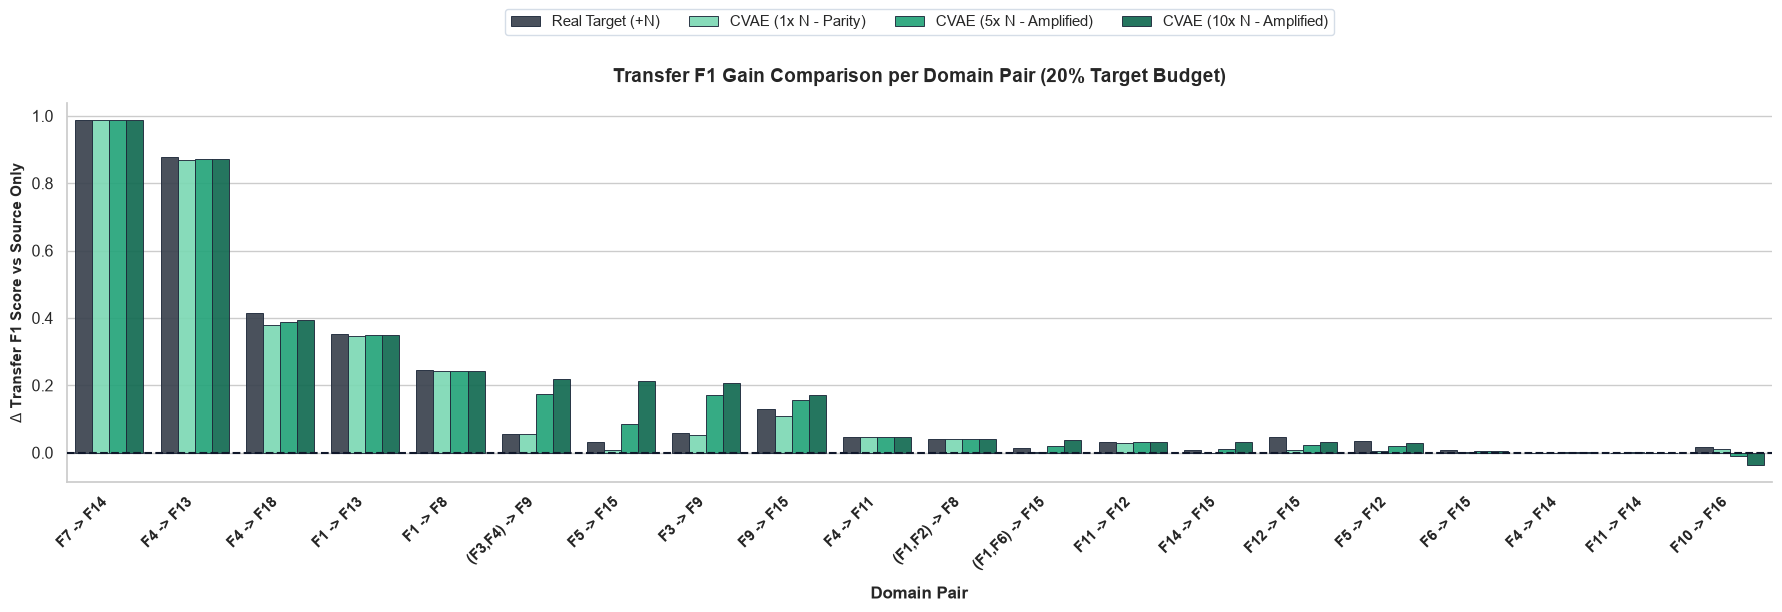

In [ ]:
sns.set_theme(style="whitegrid", font_scale=1.05)

max_pct = df_binary_budget['Percent'].max()
df_p_max = df_binary_budget[df_binary_budget['Percent'] == max_pct].copy()

if 'Gain_Real_N' not in df_p_max.columns:
    df_p_max['Gain_Real_N'] = df_p_max['F1_Real_N'] - df_p_max['F1_Source_Only']

pair_col = 'Pair' if 'Pair' in df_p_max.columns else 'name'

df_melted = df_p_max.melt(
    id_vars=[pair_col, 'Category'],
    value_vars=['Gain_Real_N', 'Gain_CVAE_1x', 'Gain_CVAE_5x', 'Gain_CVAE_10x'],
    var_name='Scenario',
    value_name='F1_Gain'
)

scenario_map = {
    'Gain_Real_N':  'Real Target (+N)',
    'Gain_CVAE_1x':  'CVAE (1x N - Parity)',
    'Gain_CVAE_5x':  'CVAE (5x N - Amplified)',
    'Gain_CVAE_10x': 'CVAE (10x N - Amplified)'
}
df_melted['Scenario'] = df_melted['Scenario'].map(scenario_map)

pair_order = df_p_max.sort_values(by='Gain_CVAE_10x', ascending=False)[pair_col].tolist()

scenario_palette = {
    'Real Target (+N)':          '#374151',  
    'CVAE (1x N - Parity)':     '#6EE7B7',  
    'CVAE (5x N - Amplified)':  '#10B981', 
    'CVAE (10x N - Amplified)': '#047857' 
}

fig, ax = plt.subplots(figsize=(18, 6.5))

sns.barplot(
    data=df_melted, x=pair_col, y='F1_Gain', hue='Scenario',
    order=pair_order, palette=scenario_palette,
    edgecolor='#1e293b', linewidth=0.7, alpha=0.92, ax=ax, zorder=2
)

ax.axhline(0, color='#0f172a', linestyle='--', linewidth=1.5, zorder=3)

ax.set_title(
    f'Transfer F1 Gain Comparison per Domain Pair ({max_pct:.0f}% Target Budget)',
    fontsize=14, fontweight='bold', pad=15
)

ax.legend(
    bbox_to_anchor=(0.5, 1.16), loc='lower center', ncol=4,
    title='', frameon=True, facecolor='white', edgecolor='#cbd5e1', fontsize=10.5
)

ax.set_xlabel('Domain Pair', fontweight='bold', fontsize=12, labelpad=10)
ax.set_ylabel(r'$\Delta$ Transfer F1 Score vs Source Only', fontweight='bold', fontsize=11)

plt.xticks(rotation=45, ha='right', fontsize=10.5)

# Rimozione dei bordi superflui
sns.despine(top=True, right=True)

plt.tight_layout()
plt.show()

Expanding the adaptation evaluation across the comprehensive 20-pair benchmark demonstrates that CVAE-based generative augmentation systematically enhances cross-domain transfer performance as both the target data budget and the synthetic volume multiplier increase. Across the four evaluation tiers (from $N = 38$ to $N = 384$) of available target data, incorporating more real target data elevates overall transfer F1 scores above the source-only baseline ($0.4961$), raising the real-only baseline itself to $0.6662$ at the maximum 20% budget. Furthermore, integrating CVAE synthetic expansions on top of these real data budgets progressively improves upon this real-only few-shot integration, with higher amplified volume multipliers ($10\times$) providing superior adaptation gains; specifically, the CVAE-$10\times$ configuration achieves a benchmark-wide average transfer F1 score of $0.6895$ at the 20% target budget.Exactly as observed across the structural analysis, the aggregate gains from real and synthetic data are heavily conditioned on the underlying physical coupling and initial feature-space divergence. For closely aligned pairs and similar mechanisms, CVAE generation successfully populates underrepresented target regions, driving down transfer penalties and maximizing adaptation gains. Conversely, for severely disjoint or unaligned pairs characterized by extreme structural separation, the CVAE samples remain constrained by irreducible manifold gaps, resulting in negligible performance recovery where transfer penalties persist near baseline collapse levels.

# PART II: Many-to-many cross-regime transfer (fault diagnosis)

In this track, we address **Fault Diagnosis** ($y \in \{0..5\}$), evaluating how well class-conditional generative models bridge **intra-mechanism covariate shifts**. We test whether synthetic augmentation can restore multiclass separation when the underlying physical fault mechanisms (classes) remain consistent, but their sensory footprints (process variables) shift dramatically between Source and Target domains.

### Deterministic Disturbance Mechanism Mapping (0..5)
Directly imported from Stage 2:

| Class ID | Mechanism Name | Included Fault IDs | Physical Description |
|---|---|---|---|
| **Class 0** | Normal State | $F0$ | Nominal steady-state operation |
| **Class 1** | Step Disturbances | $F1 \dots F7$ | Abrupt step jumps in feed flow, temperature, and cooling |
| **Class 2** | Random Variations | $F8 \dots F12$ | Persistent stochastic fluctuations in process variables |
| **Class 3** | Slow Dynamic Drift | $F13$ | Slow reaction kinetics drift in reactant C |
| **Class 4** | Actuator Stiction | $F14 \dots F15$ | Mechanical valve stiction and nonlinear actuator dynamics |
| **Class 5** | Unknown Disturbances | $F16 \dots F20$ | Unmodeled plant perturbations and unknown dynamics |


In [31]:
MECHANISM_MAP = {
    0:  (0, 'Normal', 'Nominal steady-state operation'),
    1:  (1, 'Step Disturbance', 'Faults 1-7: Abrupt step jumps in feed and cooling'),
    2:  (1, 'Step Disturbance', 'Faults 1-7'),
    3:  (1, 'Step Disturbance', 'Faults 1-7'),
    4:  (1, 'Step Disturbance', 'Faults 1-7'),
    5:  (1, 'Step Disturbance', 'Faults 1-7'),
    6:  (1, 'Step Disturbance', 'Faults 1-7'),
    7:  (1, 'Step Disturbance', 'Faults 1-7'),
    8:  (2, 'Random Variation', 'Faults 8-12: Persistent stochastic fluctuations'),
    9:  (2, 'Random Variation', 'Faults 8-12'),
    10: (2, 'Random Variation', 'Faults 8-12'),
    11: (2, 'Random Variation', 'Faults 8-12'),
    12: (2, 'Random Variation', 'Faults 8-12'),
    13: (3, 'Slow Dynamic Drift', 'Fault 13: Reaction kinetics drift in reactant C'),
    14: (4, 'Actuator Stiction', 'Faults 14-15: Mechanical valve stiction and nonlinearities'),
    15: (4, 'Actuator Stiction', 'Faults 14-15'),
    16: (5, 'Unknown Perturbation', 'Faults 16-20: Unmodeled plant disturbances'),
    17: (5, 'Unknown Perturbation', 'Faults 16-20'),
    18: (5, 'Unknown Perturbation', 'Faults 16-20'),
    19: (5, 'Unknown Perturbation', 'Faults 16-20'),
    20: (5, 'Unknown Perturbation', 'Faults 16-20'),
}

MECHANISM_NAMES = {
    0: '0: Normal',
    1: '1: Step Disturbances (F1-7)',
    2: '2: Random Variations (F8-12)',
    3: '3: Slow Drift (F13)',
    4: '4: Actuator Stiction (F14-15)',
    5: '5: Unknown Disturbances (F16-20)',
}

NUM_CLASSES_MULTICLASS = 6

def map_fault_to_mechanism(fault_id: int) -> int:
    """Map TEP fault ID (0..20) to physical disturbance mechanism category (0..5).

    Args:
        fault_id (int): TEP fault ID.

    Returns:
        int: Mechanism category index (0..5).
    """
    return MECHANISM_MAP.get(fault_id, (0, 'Normal'))[0]

def get_mechanism_features(split='train'):
    X_list, y_list = [], []
    for f in range(21):
        feats = DOMAIN_FEATURES[f][split]
        if len(feats) > 0:
            X_list.append(feats)
            y_list.append(np.full(len(feats), map_fault_to_mechanism(f)))
    return np.vstack(X_list), np.concatenate(y_list)

X_mech_train, y_mech_train = get_mechanism_features('train')
X_mech_test,  y_mech_test  = get_mechanism_features('test')

print(f'Multiclass Dataset Shapes -> Train: {X_mech_train.shape} | Test: {X_mech_test.shape}')
for c in range(NUM_CLASSES_MULTICLASS):
    print(f'  Class {c} ({MECHANISM_NAMES[c]}): {np.sum(y_mech_train == c)} train windows | {np.sum(y_mech_test == c)} test windows')

Multiclass Dataset Shapes -> Train: (40320, 208) | Test: (84000, 208)
  Class 0 (0: Normal): 1920 train windows | 4000 test windows
  Class 1 (1: Step Disturbances (F1-7)): 13440 train windows | 28000 test windows
  Class 2 (2: Random Variations (F8-12)): 9600 train windows | 20000 test windows
  Class 3 (3: Slow Drift (F13)): 1920 train windows | 4000 test windows
  Class 4 (4: Actuator Stiction (F14-15)): 3840 train windows | 8000 test windows
  Class 5 (5: Unknown Disturbances (F16-20)): 9600 train windows | 20000 test windows


### 8. Multiclass Conditional Generative Models (CVAE and CGAN)

Generators condition on the concatenation of the **one-hot mechanism label** and continuous **domain indicator** $\alpha$:
$$\mathbf{c} = [\text{one\_hot}(c_0, \dots, c_5) \;\Vert\; \alpha]$$

In [32]:
INPUT_DIM = 208
LATENT_DIM = 24
HIDDEN_DIM = 128

CVAE_TEMPERATURE = 2.0  

class MulticlassCVAE(nn.Module):
    """
    Multiclass CVAE with 128 latent neuron architecture and BatchNorm1d.
    Conditioned on one-hot class label (6D) + domain indicator alpha (1D).
    """
    def __init__(self, input_dim=INPUT_DIM, num_classes=NUM_CLASSES_MULTICLASS, latent_dim=LATENT_DIM, hidden_dim=HIDDEN_DIM):
        super().__init__()
        self.latent_dim = latent_dim
        cond_dim = num_classes + 1  # 6 classes + 1 domain indicator
        
        # Encoder: 208 + 7 = 215 in -> 128 -> 128 -> 24D latent space (mu, logvar)
        self.encoder = nn.Sequential(
            nn.Linear(input_dim + cond_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.2),
        )
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_lv = nn.Linear(hidden_dim, latent_dim)
        
        # Decoder: 24 + 7 = 31 in -> 128 -> 128 -> 208 out
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + cond_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, input_dim),
        )

    def encode(self, x, c):
        h = self.encoder(torch.cat([x, c], dim=1))
        return self.fc_mu(h), self.fc_lv(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, c):
        return self.decoder(torch.cat([z, c], dim=1))

    def forward(self, x, c):
        mu, logvar = self.encode(x, c)
        z = self.reparameterize(mu, logvar)
        return self.decode(z, c), mu, logvar
    
def cvae_loss(recon_x: torch.Tensor, x: torch.Tensor, mu: torch.Tensor, logvar: torch.Tensor, beta: float = 1e-5) -> torch.Tensor:
        """Compute CVAE loss combining L1 reconstruction error and KL divergence.

        Args:
            recon_x (torch.Tensor): Reconstructed feature batch.
            x (torch.Tensor): Ground truth target feature batch.
            mu (torch.Tensor): Latent mean vector.
            logvar (torch.Tensor): Latent log variance vector.
            beta (float): KL divergence weight hyperparameter.

        Returns:
            torch.Tensor: Scalar loss tensor.
        """

        l1 = nn.functional.l1_loss(recon_x, x, reduction='none').sum(dim=1).mean()
        kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1).mean()
        return l1 + beta * kld




### 9. Multiclass Budget-Controlled Experiment (5 Structured Pairs)

We evaluate multiclass synthetic augmentation across the **8 structured cross-mechanism domain pairs** curated in Stage 2.

In [33]:
MULTICLASS_PAIRS = [
    {
        'name': '(F1, F8, F14, F16) -> (F2, F9, F15)',
        'source_faults': [1, 8, 14, 16],          
        'target_faults': [2, 9, 15],              
        'source_split': 'train',
        'target_split': 'test',
        # Category meaning: The model learns 4 mechanisms, but the target only presents 3. 
        # Tests robustness against false positives on the missing class.
        'category': 'Missing Class in Target'
    },
    {
        'name': '(F4, F11, F14) -> (F5, F12, F15)',
        'source_faults': [4, 11, 14],             
        'target_faults': [5, 12, 15],             
        'source_split': 'train',
        'target_split': 'test',
        # Category meaning: Source and Target have the exact same classes. 
        # Tests pure geometric covariate shift without any class imbalance.
        'category': 'Perfect Class Alignment'
    },
    {
        'name': '(F3, F10, F13, F15, F20) -> (F7, F17)',
        'source_faults': [3, 10, 13, 15, 20],     
        'target_faults': [7, 17],                 
        'source_split': 'train',
        'target_split': 'test',
        # Category meaning: Model learns all 5 anomalies (high variance), but target only has 2. 
        # Tests if a very broad knowledge base helps or hinders on a narrow target.
        'category': 'Broad Source to Narrow Target'
    },
    {
        'name': '(F6, F9, F14, F18) -> (F1, F15)',
        'source_faults': [6, 9, 14, 18],          
        'target_faults': [1, 15],                 
        'source_split': 'train',
        'target_split': 'test',
        # Category meaning: A strong imbalance between trained knowledge and target evaluation.
        # Tests adaptation when the target domain shrinks to very few fault manifestations.
        'category': 'Asymmetric Domain Shift'
    }
]


TARGET_PERCENT_GRID_MULTICLASS = [0.1, 0.06, 0.15]


def train_multiclass_cvae(X_src: np.ndarray, y_src: np.ndarray, X_tgt_budget: np.ndarray, y_tgt_budget: np.ndarray, n_epochs: int = 50, beta: float = 1e-5):
    """Train Multiclass CVAE on combined Source and Target budget observations.

    Args:
        X_src (np.ndarray): Source feature matrix.
        y_src (np.ndarray): Source mechanism labels.
        X_tgt_budget (np.ndarray): Limited target budget feature matrix.
        y_tgt_budget (np.ndarray): Limited target budget mechanism labels.
        n_epochs (int): Number of training epochs.
        beta (float): KL loss weight hyperparameter.

    Returns:
        tuple[MulticlassCVAE, StandardScaler]: Trained CVAE model and fitted feature scaler.
    """

    X_all_pair = np.vstack([X_src, X_tgt_budget])
    sc = StandardScaler().fit(X_all_pair)
    sc.scale_ = np.maximum(sc.scale_, 1e-5)
    X_sc = sc.transform(X_all_pair)
    
    y_all_pair = np.concatenate([y_src, y_tgt_budget])
    
    y_oh = np.eye(NUM_CLASSES_MULTICLASS)[y_all_pair.astype(int)]
    c_domain = np.concatenate([np.zeros(len(X_src)), np.ones(len(X_tgt_budget))]).reshape(-1, 1)
    c_cond = np.hstack([y_oh, c_domain]).astype(np.float32)
    
    dataset = TensorDataset(torch.tensor(X_sc, dtype=torch.float32), torch.tensor(c_cond, dtype=torch.float32))
    ld = DataLoader(dataset, batch_size=64, shuffle=True, drop_last=False)

    set_seed(SEED)
    m_vae = MulticlassCVAE(input_dim=X_sc.shape[1], num_classes=NUM_CLASSES_MULTICLASS, latent_dim=LATENT_DIM, hidden_dim=HIDDEN_DIM).to(DEVICE)
    opt_v = optim.Adam(m_vae.parameters(), lr=1e-3)
    
    m_vae.train()
    for _ in range(n_epochs):
        for xb, cb in ld:
            xb, cb = xb.to(DEVICE), cb.to(DEVICE)
            opt_v.zero_grad()
            rec, mu, lv = m_vae(xb, cb)
            loss = cvae_loss(rec, xb, mu, lv, beta=beta)
            loss.backward()
            opt_v.step()

    m_vae.eval()
    return m_vae, sc


def eval_multiclass_rf(X_aug_raw, y_aug,
                       X_source_test_raw, y_source_test,
                       X_target_test_raw, y_target_test, fixed_scaler: StandardScaler = None):
    """Evaluates Multiclass Random Forest classifier with exact Stage 2 parity.

    Scales X_aug_raw, X_source_test_raw, and X_target_test_raw consistently using
    a scaler fitted on X_aug_raw (100% of training data) only.

    Args:
        X_aug_raw : np.ndarray
            Augmented raw training feature matrix (100% of data).
        y_aug : np.ndarray
            Augmented mechanism class labels.
        X_source_test_raw : np.ndarray
            Official held-out source test feature matrix.
        y_source_test : np.ndarray
            Official source test mechanism labels.
        X_target_test_raw : np.ndarray
            Frozen target test raw feature matrix.
        y_target_test : np.ndarray
            Frozen target test mechanism labels.
        fixed_scaler : StandardScaler, optional
            A pre-fitted StandardScaler to use for transforming the data.

    Returns:
        tuple of (float, float, float, float, float):
            Baseline Macro F1, Transfer Macro F1, Baseline Accuracy, Transfer Accuracy, and Transfer Penalty.
    """
    if fixed_scaler is None:
        fixed_scaler = StandardScaler().fit(X_aug_raw)
        fixed_scaler.scale_ = np.maximum(fixed_scaler.scale_, 1e-3)

    X_tr_sc = fixed_scaler.transform(X_aug_raw)
    X_src_te_sc = fixed_scaler.transform(X_source_test_raw)
    X_tgt_te_sc = fixed_scaler.transform(X_target_test_raw)
    rf = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
    rf.fit(X_tr_sc, y_aug)
    bl_f1 = f1_score(
        y_source_test, rf.predict(X_src_te_sc), average="macro", zero_division=0
    )
    tr_f1 = f1_score(
        y_target_test, rf.predict(X_tgt_te_sc), average="macro", zero_division=0
    )
    bl_acc = balanced_accuracy_score(y_source_test, rf.predict(X_src_te_sc))
    tr_acc = balanced_accuracy_score(y_target_test, rf.predict(X_tgt_te_sc))
    penalty_f1 = bl_f1 - tr_f1
    return bl_f1, tr_f1, bl_acc, tr_acc, penalty_f1


In [34]:
mc_budget_records = []

for pair in tqdm(MULTICLASS_PAIRS, desc='Evaluating 5 Multiclass Pairs'):
    set_seed(SEED)
    rng = np.random.default_rng(SEED)
    
    print(f"\n\nPAIR = {pair['name']} | PAIR CATEGORY = {pair['category']}")

    src_raw = pair.get('source', pair.get('source_faults', []))
    tgt_raw = pair.get('target', pair.get('target_faults', []))

    src_faults = src_raw if isinstance(src_raw, list) else [src_raw]
    tgt_faults = tgt_raw if isinstance(tgt_raw, list) else [tgt_raw]

    X_src_norm_tr = DOMAIN_FEATURES[0]['train']
    src_anom_combined = np.vstack([DOMAIN_FEATURES[f]['train'] for f in src_faults])
    y_src_anom = np.concatenate([np.full(len(DOMAIN_FEATURES[f]['train']), map_fault_to_mechanism(f)) for f in src_faults])
    
    X_src = np.vstack([X_src_norm_tr, src_anom_combined])
    y_src = np.concatenate([np.zeros(len(X_src_norm_tr)), y_src_anom])

    X_src_norm_te = DOMAIN_FEATURES[0]['test']
    src_anom_combined_te = np.vstack([DOMAIN_FEATURES[f]['test'] for f in src_faults])
    y_src_anom_te = np.concatenate([np.full(len(DOMAIN_FEATURES[f]['test']), map_fault_to_mechanism(f)) for f in src_faults])
    X_src_test = np.vstack([X_src_norm_te, src_anom_combined_te])
    y_src_test = np.concatenate([np.zeros(len(X_src_norm_te)), y_src_anom_te])

    # Official target test set (matching Stage 2 df_t_te)
    X_tgt_test = np.vstack([DOMAIN_FEATURES[0]['test']] + [DOMAIN_FEATURES[f]['test'] for f in tgt_faults])
    y_tgt_test = np.concatenate([np.zeros(len(DOMAIN_FEATURES[0]['test']))] + [np.full(len(DOMAIN_FEATURES[f]['test']), map_fault_to_mechanism(f)) for f in tgt_faults])

    X_tgt_train_anom = np.vstack([DOMAIN_FEATURES[f]['train'] for f in tgt_faults])
    y_tgt_train_anom = np.concatenate([np.full(len(DOMAIN_FEATURES[f]['train']), map_fault_to_mechanism(f)) for f in tgt_faults])
    total_tgt_train  = len(X_tgt_train_anom)
    
    fixed_scaler = StandardScaler().fit(X_src)
    fixed_scaler.scale_ = np.maximum(fixed_scaler.scale_, 1e-3)


    pre_dist = compute_distances(src_anom_combined, X_tgt_train_anom)
    _, tr_src, _, _, pen_src = eval_multiclass_rf(
        X_src,
        y_src,
        X_src_test,
        y_src_test,
        X_tgt_test,
        y_tgt_test,
        fixed_scaler=fixed_scaler,
    )
    print(f'Scenario 1 - Source-only Baseline | Target F1: {tr_src:.4f} | Penalty: {pen_src:.4f} | SWD: {pre_dist["SWD"]:.4f} | MMD: {pre_dist["MMD"]:.4f} | FD: {pre_dist["FD"]:.4f}')

    for pct in TARGET_PERCENT_GRID_MULTICLASS:
        N = max(10, int(np.round(pct * total_tgt_train)))
        print(f'\n{N} samples ({pct*100:.0f}%)')

        idx = rng.choice(total_tgt_train, N, replace=False)
        tgt_budget_anom = X_tgt_train_anom[idx]
        y_tgt_budget = y_tgt_train_anom[idx]

        # Scenario 2: Source + Real Target 
        X_real_raw = np.vstack([X_src, tgt_budget_anom])
        y_real = np.concatenate([y_src, y_tgt_budget])
        _, tr_real, _, _, pen_real = eval_multiclass_rf(
            X_real_raw,
            y_real,
            X_src_test,
            y_src_test,
            X_tgt_test,
            y_tgt_test,
            fixed_scaler=fixed_scaler,
        )
        dist_real = compute_distances(tgt_budget_anom, X_tgt_train_anom)
        print(f'Scenario 2 - Source + {N} Real Target (1x) | Target F1: {tr_real:.4f} | Penalty: {pen_real:.4f} | SWD: {dist_real["SWD"]:.4f} | MMD: {dist_real["MMD"]:.4f} | FD: {dist_real["FD"]:.4f}')

        set_seed(SEED)
        m_mc_vae, sc_mc = train_multiclass_cvae(X_src, y_src, tgt_budget_anom, y_tgt_budget, n_epochs=50, beta=1e-5)

        mc_data = np.vstack([X_src, tgt_budget_anom])
        mc_margin = 0.20 * (mc_data.max(axis=0) - mc_data.min(axis=0))
        lower_bound = sc_mc.transform((mc_data.min(axis=0) - mc_margin).reshape(1, -1)).squeeze()
        upper_bound = sc_mc.transform((mc_data.max(axis=0) + mc_margin).reshape(1, -1)).squeeze()

        tgt_classes, counts = np.unique(y_tgt_budget, return_counts=True)
        
        syn_1x_list, lbl_1x_list = [], []
        syn_5x_list, lbl_5x_list = [], []
        syn_10x_list, lbl_10x_list = [], []

        m_mc_vae.eval()
        with torch.no_grad():
            for tc, cnt in zip(tgt_classes, counts):
                oh_class = np.eye(NUM_CLASSES_MULTICLASS)[int(tc)]
                
                n1 = max(1, int(np.round(1 * cnt)))
                c1 = torch.tensor(np.tile(np.append(oh_class, 1.0), (n1, 1)), dtype=torch.float32, device=DEVICE)
                zv1 = torch.randn(n1, LATENT_DIM, device=DEVICE) * CVAE_TEMPERATURE
                syn1 = np.clip(m_mc_vae.decode(zv1, c1).cpu().numpy(), lower_bound, upper_bound)
                syn_1x_list.append(syn1)
                lbl_1x_list.append(np.full(n1, tc))

                n5 = max(1, int(np.round(5 * cnt)))
                c5 = torch.tensor(np.tile(np.append(oh_class, 1.0), (n5, 1)), dtype=torch.float32, device=DEVICE)
                zv5 = torch.randn(n5, LATENT_DIM, device=DEVICE) * CVAE_TEMPERATURE
                syn5 = np.clip(m_mc_vae.decode(zv5, c5).cpu().numpy(), lower_bound, upper_bound)
                syn_5x_list.append(syn5)
                lbl_5x_list.append(np.full(n5, tc))

                n10 = max(1, int(np.round(10 * cnt)))
                c10 = torch.tensor(np.tile(np.append(oh_class, 1.0), (n10, 1)), dtype=torch.float32, device=DEVICE)
                zv10 = torch.randn(n10, LATENT_DIM, device=DEVICE) * CVAE_TEMPERATURE
                syn10 = np.clip(m_mc_vae.decode(zv10, c10).cpu().numpy(), lower_bound, upper_bound)
                syn_10x_list.append(syn10)
                lbl_10x_list.append(np.full(n10, tc))

        syn_v1 = np.vstack(syn_1x_list)
        lbl_v1 = np.concatenate(lbl_1x_list)
        
        syn_v5 = np.vstack(syn_5x_list)
        lbl_v5 = np.concatenate(lbl_5x_list)
        
        syn_v10 = np.vstack(syn_10x_list)
        lbl_v10 = np.concatenate(lbl_10x_list)

        syn_v1_raw  = sc_mc.inverse_transform(syn_v1)
        syn_v5_raw  = sc_mc.inverse_transform(syn_v5)
        syn_v10_raw = sc_mc.inverse_transform(syn_v10)

        # Scenario 3: Source + Synthetic 1x N
        _, tr_v1, _, _, pen_v1 = eval_multiclass_rf(
        np.vstack([X_src, syn_v1_raw]),
        np.concatenate([y_src, lbl_v1]),
        X_src_test,
        y_src_test,
        X_tgt_test,
        y_tgt_test,
        fixed_scaler=fixed_scaler,
        )
        dist_v1 = compute_distances(syn_v1_raw, X_tgt_train_anom)
        print(f'Scenario 3 - Source + {N} Synthetic (1x) | Target F1: {tr_v1:.4f} | Penalty: {pen_v1:.4f} | SWD: {dist_v1["SWD"]:.4f} | MMD: {dist_v1["MMD"]:.4f} | FD: {dist_v1["FD"]:.4f}')

        # Scenario 4: Source + Synthetic 5x N
        _, tr_v5, _, _, pen_v5 = eval_multiclass_rf(
            np.vstack([X_src, syn_v5_raw]),
            np.concatenate([y_src, lbl_v5]),
            X_src_test,
            y_src_test,
            X_tgt_test,
            y_tgt_test,
            fixed_scaler=fixed_scaler,
        )
        dist_v5 = compute_distances(syn_v5_raw, X_tgt_train_anom)
        print(f'Scenario 4 - Source + {5 * N} Synthetic (5x) | Target F1: {tr_v5:.4f} | Penalty: {pen_v5:.4f} | SWD: {dist_v5["SWD"]:.4f} | MMD: {dist_v5["MMD"]:.4f} | FD: {dist_v5["FD"]:.4f}')

        # Scenario 5: Source + Synthetic 10x N
        _, tr_v10, _, _, pen_v10 = eval_multiclass_rf(
            np.vstack([X_src, syn_v10_raw]),
            np.concatenate([y_src, lbl_v10]),
            X_src_test,
            y_src_test,
            X_tgt_test,
            y_tgt_test,
            fixed_scaler=fixed_scaler,
        )
        dist_v10 = compute_distances(syn_v10_raw, X_tgt_train_anom)
        print(f'Scenario 5 - Source + {10 * N} Synthetic (10x) | Target F1: {tr_v10:.4f} | Penalty: {pen_v10:.4f} | SWD: {dist_v10["SWD"]:.4f} | MMD: {dist_v10["MMD"]:.4f} | FD: {dist_v10["FD"]:.4f}')

        mc_budget_records.append({
            'Pair': pair['name'], 'Category': pair['category'], 'Percent': pct * 100, 'N': N,
            'Pre_SWD': pre_dist['SWD'], 'Pre_MMD': pre_dist['MMD'], 'Pre_FD': pre_dist['FD'],
            # Scenario 1: Source only
            'F1_Source_Only': tr_src, 'Penalty_Source_Only': pen_src,
            # Scenario 2: Real N
            'F1_Real_N': tr_real, 'Penalty_Real_N': pen_real, 'SWD_Real_N': dist_real['SWD'], 'MMD_Real_N': dist_real['MMD'], 'FD_Real_N': dist_real['FD'],
            # Scenario 3: Synth 1x N (Parity)
            'F1_CVAE_1x': tr_v1, 'Penalty_CVAE_1x': pen_v1, 'SWD_CVAE_1x': dist_v1['SWD'], 'MMD_CVAE_1x': dist_v1['MMD'], 'FD_CVAE_1x': dist_v1['FD'],
            # Scenario 4: Synth 5x N (Amplification)
            'F1_CVAE_5x': tr_v5, 'Penalty_CVAE_5x': pen_v5, 'SWD_CVAE_5x': dist_v5['SWD'], 'MMD_CVAE_5x': dist_v5['MMD'], 'FD_CVAE_5x': dist_v5['FD'],
            # Scenario 5: Synth 10x N (Amplification)
            'F1_CVAE_10x': tr_v10, 'Penalty_CVAE_10x': pen_v10, 'SWD_CVAE_10x': dist_v10['SWD'], 'MMD_CVAE_10x': dist_v10['MMD'], 'FD_CVAE_10x': dist_v10['FD'],
            
            'Gain_CVAE_1x': tr_v1 - tr_src,
            'Gain_CVAE_5x': tr_v5 - tr_src,
            'Gain_CVAE_10x': tr_v10 - tr_src,
        })

df_mc_budget = pd.DataFrame(mc_budget_records)

summary_mc = df_mc_budget.groupby('Percent').agg({
    'N': 'mean',
    'F1_Source_Only': 'mean',
    'F1_Real_N': 'mean',
    'F1_CVAE_1x': 'mean',
    'F1_CVAE_5x': 'mean',
    'F1_CVAE_10x': 'mean',
    'Pre_SWD': 'mean',
    'Pre_MMD': 'mean',
    'Pre_FD': 'mean',
    'SWD_Real_N': 'mean',
    'MMD_Real_N': 'mean',
    'FD_Real_N': 'mean',
    'SWD_CVAE_1x': 'mean',
    'MMD_CVAE_1x': 'mean',
    'FD_CVAE_1x': 'mean',
    'SWD_CVAE_5x': 'mean',
    'MMD_CVAE_5x': 'mean',
    'FD_CVAE_5x': 'mean',
    'SWD_CVAE_10x': 'mean',
    'MMD_CVAE_10x': 'mean',
    'FD_CVAE_10x': 'mean',
}).reset_index()

print('\nMulticlass Summary Table (Averaged across all pairs)')
display(summary_mc.round(4))


Evaluating 5 Multiclass Pairs:   0%|          | 0/4 [00:00<?, ?it/s]



PAIR = (F1, F8, F14, F16) -> (F2, F9, F15) | PAIR CATEGORY = Missing Class in Target
Scenario 1 - Source-only Baseline | Target F1: 0.0969 | Penalty: 0.8484 | SWD: 0.4173 | MMD: 0.0812 | FD: 203.7444

576 samples (10%)
Scenario 2 - Source + 576 Real Target (1x) | Target F1: 0.2926 | Penalty: 0.6512 | SWD: 0.0486 | MMD: 0.0013 | FD: 4.3075
Scenario 3 - Source + 576 Synthetic (1x) | Target F1: 0.1121 | Penalty: 0.8319 | SWD: 0.6287 | MMD: 0.1197 | FD: 321.4964
Scenario 4 - Source + 2880 Synthetic (5x) | Target F1: 0.1492 | Penalty: 0.7949 | SWD: 0.4401 | MMD: 0.0919 | FD: 216.5136
Scenario 5 - Source + 5760 Synthetic (10x) | Target F1: 0.1216 | Penalty: 0.8180 | SWD: 0.4119 | MMD: 0.0818 | FD: 206.4897

346 samples (6%)
Scenario 2 - Source + 346 Real Target (1x) | Target F1: 0.2921 | Penalty: 0.6533 | SWD: 0.0591 | MMD: 0.0021 | FD: 7.4970
Scenario 3 - Source + 346 Synthetic (1x) | Target F1: 0.1682 | Penalty: 0.7790 | SWD: 0.7475 | MMD: 0.1313 | FD: 388.7113
Scenario 4 - Source + 1730

Evaluating 5 Multiclass Pairs:  25%|██▌       | 1/4 [06:08<18:24, 368.06s/it]

Scenario 5 - Source + 8640 Synthetic (10x) | Target F1: 0.1897 | Penalty: 0.7504 | SWD: 0.4022 | MMD: 0.0676 | FD: 206.5796


PAIR = (F4, F11, F14) -> (F5, F12, F15) | PAIR CATEGORY = Perfect Class Alignment
Scenario 1 - Source-only Baseline | Target F1: 0.3198 | Penalty: 0.6561 | SWD: 0.4446 | MMD: 0.0955 | FD: 250.8926

576 samples (10%)
Scenario 2 - Source + 576 Real Target (1x) | Target F1: 0.6556 | Penalty: 0.3210 | SWD: 0.0515 | MMD: 0.0011 | FD: 6.4737
Scenario 3 - Source + 576 Synthetic (1x) | Target F1: 0.2702 | Penalty: 0.7101 | SWD: 0.3758 | MMD: 0.1036 | FD: 179.9115
Scenario 4 - Source + 2880 Synthetic (5x) | Target F1: 0.2885 | Penalty: 0.6952 | SWD: 0.4094 | MMD: 0.1105 | FD: 212.1990
Scenario 5 - Source + 5760 Synthetic (10x) | Target F1: 0.2210 | Penalty: 0.7631 | SWD: 0.4619 | MMD: 0.1210 | FD: 265.6005

346 samples (6%)
Scenario 2 - Source + 346 Real Target (1x) | Target F1: 0.6276 | Penalty: 0.3497 | SWD: 0.0714 | MMD: 0.0020 | FD: 16.8329
Scenario 3 - Source + 346 

Evaluating 5 Multiclass Pairs:  50%|█████     | 2/4 [10:28<10:09, 304.89s/it]

...

Evaluating 5 Multiclass Pairs:  75%|███████▌  | 3/4 [17:18<05:52, 352.73s/it]

Scenario 5 - Source + 5760 Synthetic (10x) | Target F1: 0.1708 | Penalty: 0.4995 | SWD: 0.5526 | MMD: 0.1362 | FD: 237.6309


PAIR = (F6, F9, F14, F18) -> (F1, F15) | PAIR CATEGORY = Asymmetric Domain Shift
Scenario 1 - Source-only Baseline | Target F1: 0.1781 | Penalty: 0.6083 | SWD: 0.5179 | MMD: 0.1462 | FD: 227.0928

384 samples (10%)
Scenario 2 - Source + 384 Real Target (1x) | Target F1: 0.2972 | Penalty: 0.4896 | SWD: 0.0565 | MMD: 0.0017 | FD: 4.7871
Scenario 3 - Source + 384 Synthetic (1x) | Target F1: 0.2944 | Penalty: 0.4940 | SWD: 1.0650 | MMD: 0.3028 | FD: 569.5276
Scenario 4 - Source + 1920 Synthetic (5x) | Target F1: 0.2995 | Penalty: 0.4891 | SWD: 0.7217 | MMD: 0.2819 | FD: 274.1535
Scenario 5 - Source + 3840 Synthetic (10x) | Target F1: 0.2981 | Penalty: 0.4915 | SWD: 0.6383 | MMD: 0.2666 | FD: 220.9830

230 samples (6%)
Scenario 2 - Source + 230 Real Target (1x) | Target F1: 0.2967 | Penalty: 0.4902 | SWD: 0.0780 | MMD: 0.0025 | FD: 10.4355
Scenario 3 - Source + 230 S

Evaluating 5 Multiclass Pairs: 100%|██████████| 4/4 [22:27<00:00, 336.96s/it]

Scenario 5 - Source + 5760 Synthetic (10x) | Target F1: 0.2989 | Penalty: 0.4911 | SWD: 0.5711 | MMD: 0.2366 | FD: 192.5033

Multiclass Summary Table (Averaged across all pairs)


,Percent,N,F1_Source_Only,F1_Real_N,F1_CVAE_1x,F1_CVAE_5x,F1_CVAE_10x,Pre_SWD,Pre_MMD,Pre_FD,...,FD_Real_N,SWD_CVAE_1x,MMD_CVAE_1x,FD_CVAE_1x,SWD_CVAE_5x,MMD_CVAE_5x,FD_CVAE_5x,SWD_CVAE_10x,MMD_CVAE_10x,FD_CVAE_10x
0,6.0,288.0,0.1774,0.3970,0.2086,0.2128,0.1847,0.4363,0.1016,198.9696,...,10.9165,0.6882,0.1599,366.0705,0.5347,0.1499,235.1716,0.5106,0.1481,221.6862
1,10.0,480.0,0.1774,0.4081,0.2013,0.2283,0.2009,0.4363,0.1016,198.9696,...,4.9027,0.6161,0.1566,300.4017,0.5042,0.1487,216.2023,0.5016,0.1473,222.9848
2,15.0,720.0,0.1774,0.4075,0.2342,0.2343,0.2468,0.4363,0.1016,198.9696,...,4.2160,0.5733,0.1592,264.8357,0.4929,0.1452,213.0976,0.5098,0.1450,237.5506


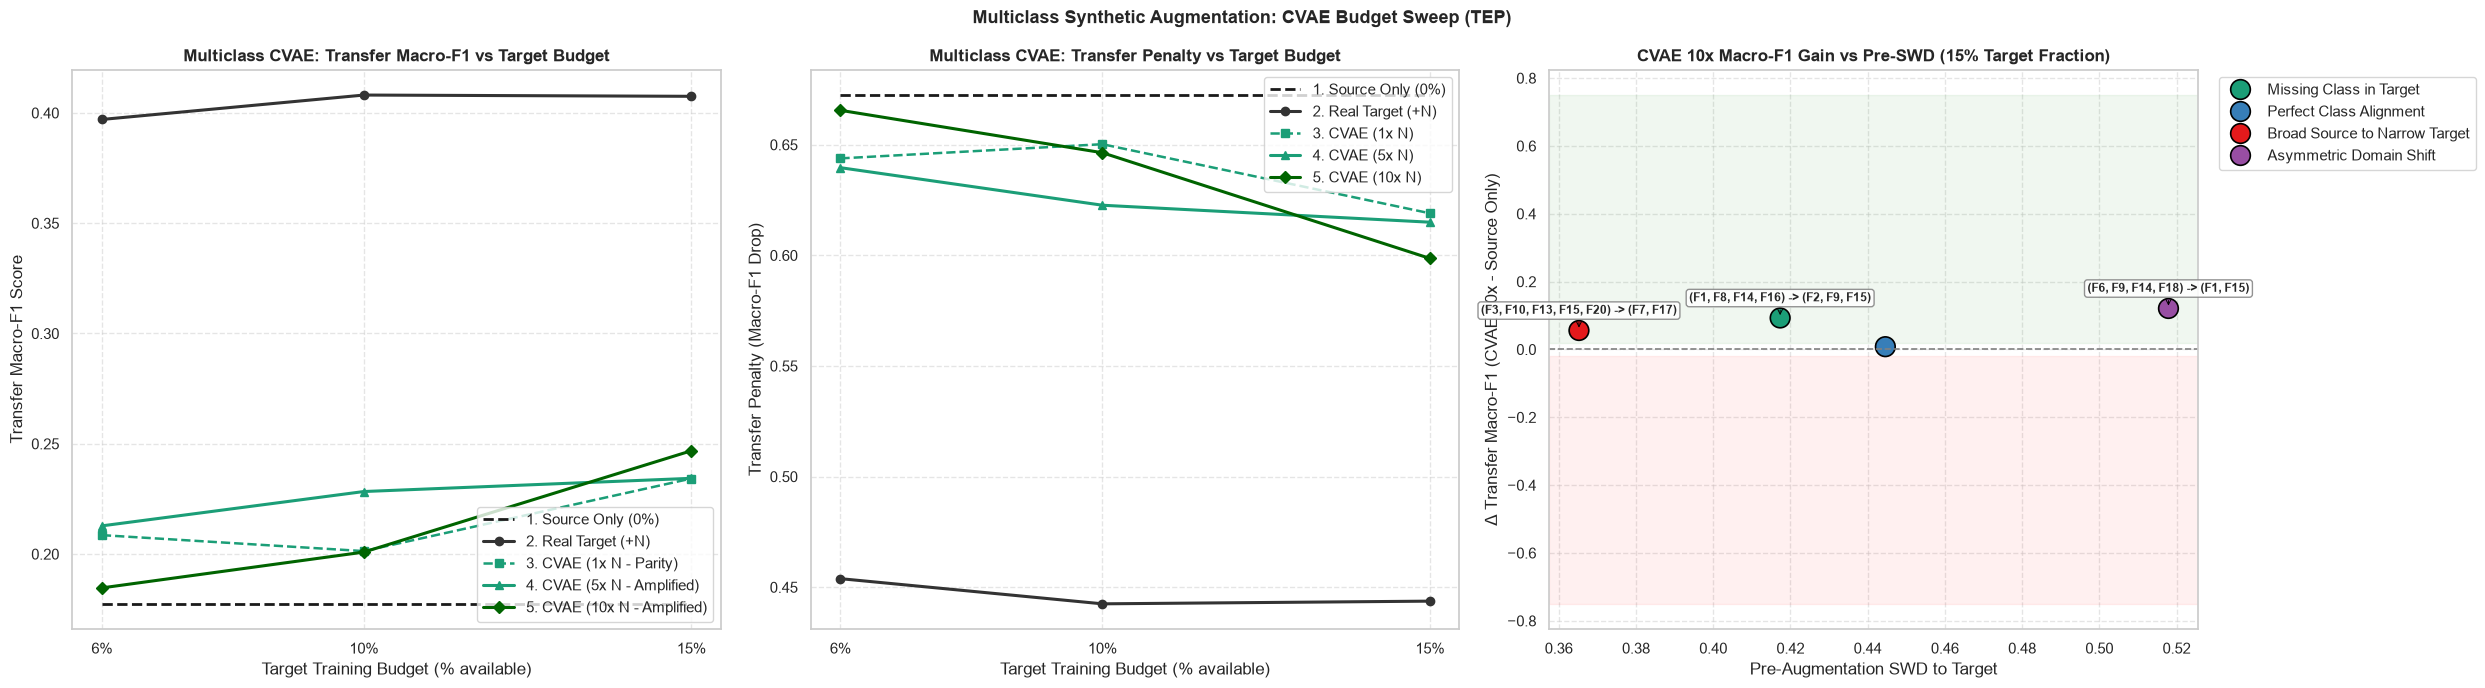

In [36]:
PAIR_CATEGORY_PALETTE = {
    'Missing Class in Target': '#1b9e77',         # Verde
    'Perfect Class Alignment': '#377eb8',         # Blu
    'Broad Source to Narrow Target': '#e41a1c',   # Rosso
    'Asymmetric Domain Shift': '#984ea3'          # Viola
}

fig, axes = plt.subplots(1, 3, figsize=(25, 7))

avg_pct = summary_mc.copy()
pct_ticks = sorted(avg_pct['Percent'].unique())
pct_labels = [f"{int(p) if p.is_integer() else p:.0f}%" for p in pct_ticks]

axes[0].plot(avg_pct['Percent'], avg_pct['F1_Source_Only'], 'k--', lw=2, label='1. Source Only (0%)')
axes[0].plot(avg_pct['Percent'], avg_pct['F1_Real_N'], 'o-', color='#333333', lw=2.2, label='2. Real Target (+N)')
axes[0].plot(avg_pct['Percent'], avg_pct['F1_CVAE_1x'], 's--', color='#1b9e77', lw=1.8, label='3. CVAE (1x N - Parity)')
axes[0].plot(avg_pct['Percent'], avg_pct['F1_CVAE_5x'], '^-', color='#1b9e77', lw=2.2, label='4. CVAE (5x N - Amplified)')
axes[0].plot(avg_pct['Percent'], avg_pct['F1_CVAE_10x'], 'D-', color='#006400', lw=2.2, label='5. CVAE (10x N - Amplified)')

axes[0].set_title('Multiclass CVAE: Transfer Macro-F1 vs Target Budget', fontweight='bold')
axes[0].set_xlabel('Target Training Budget (% available)')
axes[0].set_ylabel('Transfer Macro-F1 Score')
axes[0].set_xticks(pct_ticks)
axes[0].set_xticklabels(pct_labels)
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend(loc='lower right')

avg_penalty = df_mc_budget.groupby('Percent').mean(numeric_only=True).reset_index()

axes[1].plot(avg_penalty['Percent'], avg_penalty['Penalty_Source_Only'], 'k--', lw=2, label='1. Source Only (0%)')
axes[1].plot(avg_penalty['Percent'], avg_penalty['Penalty_Real_N'], 'o-', color='#333333', lw=2.2, label='2. Real Target (+N)')
axes[1].plot(avg_penalty['Percent'], avg_penalty['Penalty_CVAE_1x'], 's--', color='#1b9e77', lw=1.8, label='3. CVAE (1x N)')
axes[1].plot(avg_penalty['Percent'], avg_penalty['Penalty_CVAE_5x'], '^-', color='#1b9e77', lw=2.2, label='4. CVAE (5x N)')
axes[1].plot(avg_penalty['Percent'], avg_penalty['Penalty_CVAE_10x'], 'D-', color='#006400', lw=2.2, label='5. CVAE (10x N)')

axes[1].set_title('Multiclass CVAE: Transfer Penalty vs Target Budget', fontweight='bold')
axes[1].set_xlabel('Target Training Budget (% available)')
axes[1].set_ylabel('Transfer Penalty (Macro-F1 Drop)')
axes[1].set_xticks(pct_ticks)
axes[1].set_xticklabels(pct_labels)
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(loc='upper right')

max_pct = df_mc_budget['Percent'].max()
df_p_max = df_mc_budget[df_mc_budget['Percent'] == max_pct].copy()

axes[2].axhspan(0.02, 0.75, color='green', alpha=0.06)
axes[2].axhspan(-0.75, -0.02, color='red', alpha=0.06)
axes[2].axhline(0, color='gray', linestyle='--', linewidth=1.2)

sns.scatterplot(
    data=df_p_max, x='Pre_SWD', y='Gain_CVAE_10x', hue='Category',
    palette=PAIR_CATEGORY_PALETTE, s=200, edgecolor='black', linewidth=1.2, ax=axes[2]
)

for _, row in df_p_max.iterrows():
    if abs(row['Gain_CVAE_10x']) > 0.03 or row['Pre_SWD'] > 0.5:
        offset_y = 12 if row['Gain_CVAE_10x'] >= 0 else -18
        axes[2].annotate(
            row['Pair'], 
            (row['Pre_SWD'], row['Gain_CVAE_10x']),
            textcoords="offset points", 
            xytext=(0, offset_y),
            ha='center', fontsize=8.5, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="gray", alpha=0.85),
            arrowprops=dict(arrowstyle="->", color="black", lw=0.7)
        )

axes[2].set_title(f'CVAE 10x Macro-F1 Gain vs Pre-SWD ({max_pct:.0f}% Target Fraction)', fontweight='bold')
axes[2].set_xlabel('Pre-Augmentation SWD to Target')
axes[2].set_ylabel(r'$\Delta$ Transfer Macro-F1 (CVAE 10x - Source Only)')
axes[2].grid(True, linestyle='--', alpha=0.5)
axes[2].legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)

plt.suptitle('Multiclass Synthetic Augmentation: CVAE Budget Sweep (TEP)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Evaluating multiclass covariate shift dynamics across the 4 core benchmark pairs reveals distinct structural limits when shifting decision boundaries across diverse sensory footprints. As target sample budgets expand from $N = 288.0$ to $N = 720.0$ ($15\%$ target fraction), incorporating more real target data steadily elevates macro-F1 performance from a source-only baseline of $0.1774$ up to a real-only target peak of $0.4081$. However, unlike single-fault tasks, introducing CVAE-based synthetic augmentation in this highly complex multi-state setup does not surpass the real-only baseline; instead, amplified synthetic configurations (such as CVAE-10x) achieve a macro-F1 of $0.2468$ at higher budgets. 

Granular inspection indicates that this behavior is driven by the extreme geometric difficulty of simultaneously bridging multiple distinct classes across vast covariate shifts. Even though these pairs map identical physical categories (e.g., bridging Step Disturbances on different sensors), they exhibit severe pre-adaptation feature divergence (average $\text{SWD} \approx 0.43$, $\text{FD} \approx 198$). Consequently, these deep spatial divides restrict generative bridging: the continuous spatial gap is too severe for the CVAE to reliably reconstruct overlapping boundaries using only a few-shot target budget. Synthetic samples encounter structural limits (though still providing a modest $+0.07$ gain over the source-only baseline), while real-data integration remains the absolute primary driver of adaptation gains in multi-fault regimes.

# Final discoveries of stage 3:
The investigation successfully establishes a unified and rigorous methodological bridge between industrial fault detection (evaluated across 20 binary source-target pairs) and advanced fault diagnosis (encompassing 4 covariate-shift multiclass transfer configurations). This work provides a comprehensive framework to characterize, predict, and mitigate domain shift phenomena in complex cyber-physical systems like the Tennessee Eastman Process.

* **Global Distance-Penalty Correlation (Binary Track):** Across the 20-pair binary benchmark, feature-space divergence strongly correlates with model degradation. Optimal transport (SWD), kernel (MMD), and moment-based (FD) metrics demonstrate statistically significant monotonic relationships with Random Forest transfer penalties.

* **Geometric Divergence as a Governing Limit:** Transfer performance and generative bridging are strictly dictated by the geometric divergence of the underlying plant physics. While the Binary track showed that single-fault synthetic bridging is highly effective, the Multiclass track proves that simultaneous, multi-class covariate shifts create feature-space incompatibilities too vast for standard CVAE augmentation to fully resolve autonomously.

* **Synthetic vs. Real Data Dynamics in Few-Shot Adaptation:** 
    - **In the Binary Track**, CVAE-based multi-volume synthetic expansions (particularly at $10\times$ volume) consistently outperform real-only few-shot learning as target budgets scale from $2\%$ to $20\%$, elevating benchmark-wide average transfer F1 scores up to $0.6895$ for CVAE-10x at the $20\%$ budget ($N = 384$), compared to the source-only baseline of $0.4961$ and real-only baseline of $0.6662$.
    - **In the Multiclass Track**, simultaneous extreme covariate shifts prevent CVAE-based synthetic data from surpassing the real-only baseline. Due to severe pre-adaptation spatial divergence ($\text{SWD} \approx 0.43$), synthetic generation hits hard structural ceilings. At a $15\%$ budget ($N = 720$), CVAE-10x yields a macro-F1 of $0.2468$, which provides a modest gain over the source-only baseline ($0.1774$) but falls drastically short of the real-only target peak ($0.4081$). This demonstrates that while generative AI bridges targeted binary shifts successfully, resolving massive, multi-dimensional covariate shifts across an entire operational taxonomy requires real-target data scaling as the sole effective driver of adaptation gains.